# Bibliotecas

In [1]:
import pandas               as pd
import numpy                as np
import matplotlib.pyplot    as plt
import seaborn              as sns
import statsmodels.api      as sm
import networkx             as nx
import math
import joblib
import json
import shap

from sklearn.model_selection    import train_test_split, RandomizedSearchCV
from sklearn.preprocessing      import RobustScaler, MinMaxScaler
from sklearn.metrics            import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    ConfusionMatrixDisplay,
    precision_recall_curve
    )
from sklearn.pipeline       import Pipeline
from scipy.stats            import gaussian_kde, randint
from sklearn.calibration    import calibration_curve
from xgboost                import XGBClassifier
from sklearn.ensemble       import RandomForestClassifier

# Funções

In [2]:
def plot_curva_roc_auc(y_test, y_probs):
    """
    Plota a Curva ROC e calcula o AUC (Area Under the Curve) para avaliar o desempenho do modelo de classificação.
    """
    auc = roc_auc_score(y_test, y_probs)
    print(f"ROC AUC Score: {auc:.2f}")

    # Plotando a Curva ROC
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc:.2f}')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')
    plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
    plt.ylabel('Taxa de Verdadeiro Positivo (Sensibilidade/Recall)')
    plt.title(f'Curva ROC')
    plt.legend()
    plt.show()

In [3]:
def plot_analise_threshold(y_test, y_probs):
    """
    Plota a Curva Precision-Recall para avaliar o desempenho do modelo de classificação.
    """
    precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
    df_precision_recall = pd.DataFrame({
        'Precision':    precision,
        'Recall':       recall,
        'Threshold':    np.append(thresholds, 1.0)
    })

    f1 = 2 * (df_precision_recall['Precision'] * df_precision_recall['Recall']) / (
        df_precision_recall['Precision'] + df_precision_recall['Recall']
    )

    best_idx = np.argmax(f1)
    best_threshold = df_precision_recall['Threshold'].iloc[best_idx]

    plt.figure(figsize=(10,6))
    plt.grid()

    plt.plot(df_precision_recall['Threshold'], df_precision_recall['Precision'], label='Precision')
    plt.plot(df_precision_recall['Threshold'], df_precision_recall['Recall'], label='Recall')
    plt.plot(df_precision_recall['Threshold'], f1, label='F1 Score', color='green')

    plt.axvline(best_threshold, color='red', linestyle='--',
                label=f'Best Threshold: {best_threshold:.2f}')

    plt.legend()
    plt.grid()
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title(f'Precision/Recall vs Threshold com ótimo F1 - Threshold ótimo: {best_threshold:.2f}')

    plt.show()

    return best_threshold

In [4]:
def network_corr(data, corr, corr_interval=[-0.75, 0.75]):
    """
    Plota uma rede de correlação entre as variáveis do DataFrame `data` com base na matriz de correlação `corr`.
    Apenas as correlações que estão fora do intervalo definido por `corr_interval` serão exibidas na rede.
    """
    corr = pd.melt(corr.reset_index(), id_vars='index')
    corr.columns = ['x', 'y', 'value']
    high_corr = corr[((corr['value'] <= corr_interval[0]) | (corr['value'] >= corr_interval[1]))]
    high_corr = high_corr[(high_corr['value'] != 1)].reset_index(drop=True)
    sources = list(high_corr.x.unique())
    targets = list(high_corr.y.unique())
    plt.figure(figsize=(10, 10))
    g = nx.from_pandas_edgelist(high_corr, source='x', target='y') 
    layout = nx.spring_layout(g, iterations=50, k=0.6, seed=123)
    target_size = [g.degree(t) * 20 for t in targets]
    nx.draw_networkx_nodes(g, 
                           layout, 
                           nodelist=targets, 
                           node_size=target_size)
    # Draw every connection
    nx.draw_networkx_nodes(g, layout, nodelist=sources, node_size=400, alpha=0.5)

    nx.draw_networkx_edges(g, layout, width=1)

    target_dict = dict(zip(targets, targets))
    nx.draw_networkx_labels(g, layout, labels=target_dict)

    plt.axis('off')
    plt.title(f" Rede de Correlação com Intervalo {corr_interval}", fontsize=12)
    plt.show()

# Dataset

In [5]:
dataset = pd.read_csv('dados_brutos\\tarefas_clientes_treino_teste.csv', sep=';')
# Convertendo colunas object com vírgula para float numérico
colunas_para_ajustar = list(dataset.filter(regex='perc').columns) + \
                        list(dataset.filter(regex='score').columns) + \
                        list(dataset.filter(regex='valor').columns) + \
                        list(dataset.filter(regex='media').columns)

for col in colunas_para_ajustar:
    dataset[col] = dataset[col].astype(str).str.replace(',', '.').astype(float)

dataset.head()

,cod_cliente,valor_medio_contrato,meses_vida_cliente,qt_tarefas_total,media_dias_exec,qt_tarefas_sd,media_dias_exec_tarefa_sd,perc_qt_tarefas_sd,qt_tarefas_hd,media_dias_exec_tarefa_hd,...,perc_qt_tarefas_bug,qt_categorias_distintas,qt_subcategorias_distintas,qt_grupos_envolvidos,perc_qt_prioridade_normal,perc_qt_prioridade_parcial,perc_qt_prioridade_urgente,perc_qt_prioridade_maxima,perc_qt_prioridade_reforco,churn
0,43637,1037.88,26,476,0.0840,0,0.0,0.0,0,0.0000,...,0.0,3,6,3,100.00000,0.00000,0.0,0.0,0.0,1
1,45284,0.00,37,15,0.2667,0,0.0,0.0,11,0.3636,...,0.0,4,7,4,80.00000,0.00000,20.0,0.0,0.0,0
2,45852,468.06,20,3,0.3333,0,0.0,0.0,0,0.0000,...,0.0,3,3,1,66.66667,33.33333,0.0,0.0,0.0,0
3,46365,300.00,0,3,0.3333,0,0.0,0.0,0,0.0000,...,0.0,3,3,1,100.00000,0.00000,0.0,0.0,0.0,1
4,46396,332.01,12,3,0.3333,0,0.0,0.0,0,0.0000,...,0.0,3,3,0,100.00000,0.00000,0.0,0.0,0.0,0


In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4068 entries, 0 to 4067
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_cliente                 4068 non-null   int64  
 1   valor_medio_contrato        4068 non-null   float64
 2   meses_vida_cliente          4068 non-null   int64  
 3   qt_tarefas_total            4068 non-null   int64  
 4   media_dias_exec             4068 non-null   float64
 5   qt_tarefas_sd               4068 non-null   int64  
 6   media_dias_exec_tarefa_sd   4068 non-null   float64
 7   perc_qt_tarefas_sd          4068 non-null   float64
 8   qt_tarefas_hd               4068 non-null   int64  
 9   media_dias_exec_tarefa_hd   4068 non-null   float64
 10  perc_qt_tarefas_hd          4068 non-null   float64
 11  qt_tarefas_reclamacao       4068 non-null   int64  
 12  media_dias_exec_reclamacao  4068 non-null   float64
 13  perc_qt_tarefas_reclamacao  4068 

In [7]:
# Análise dos valores das colunas de média para churn e não churn
colunas_media = list(dataset.filter(regex='media').columns)

for c in colunas_media:
    mediana_churn = dataset[dataset['churn'] == 1][c].median().round(2)
    mediana_nao_churn = dataset[dataset['churn'] == 0][c].median().round(2)

    media_churn = dataset[dataset['churn'] == 1][c].mean().round(2)
    media_nao_churn = dataset[dataset['churn'] == 0][c].mean().round(2)

    desv_pad_churn = dataset[dataset['churn'] == 1][c].std().round(2)
    desv_pad_nao_churn = dataset[dataset['churn'] == 0][c].std().round(2)

    print(c)
    print(f'Mediana para Churn:             {mediana_churn}')
    print(f'Mediana para Não Churn:         {mediana_nao_churn} \n')
    print(f'Média para Churn:               {media_churn}')
    print(f'Média para Não Churn:           {media_nao_churn} \n')
    print(f'Desvio Padrão para Churn:       {desv_pad_churn}')
    print(f'Desvio Padrão para Não Churn:   {desv_pad_nao_churn} \n')
    print('*' * 30)

media_dias_exec
Mediana para Churn:             15.24
Mediana para Não Churn:         12.95 

Média para Churn:               25.09
Média para Não Churn:           17.34 

Desvio Padrão para Churn:       32.86
Desvio Padrão para Não Churn:   17.63 

******************************
media_dias_exec_tarefa_sd
Mediana para Churn:             0.0
Mediana para Não Churn:         4.22 

Média para Churn:               6.01
Média para Não Churn:           8.39 

Desvio Padrão para Churn:       15.72
Desvio Padrão para Não Churn:   18.03 

******************************
media_dias_exec_tarefa_hd
Mediana para Churn:             5.67
Mediana para Não Churn:         2.46 

Média para Churn:               7.24
Média para Não Churn:           3.65 

Desvio Padrão para Churn:       7.87
Desvio Padrão para Não Churn:   4.39 

******************************
media_dias_exec_reclamacao
Mediana para Churn:             0.0
Mediana para Não Churn:         0.0 

Média para Churn:               1.47
Média para

In [8]:
# Análise dos valores das colunas de quantidade para churn e não churn
colunas_qt = list(dataset.filter(regex='qt').columns)

for c in colunas_qt:
    mediana_churn = dataset[dataset['churn'] == 1][c].median().round(2)
    mediana_nao_churn = dataset[dataset['churn'] == 0][c].median().round(2)

    media_churn = dataset[dataset['churn'] == 1][c].mean().round(2)
    media_nao_churn = dataset[dataset['churn'] == 0][c].mean().round(2)

    desv_pad_churn = dataset[dataset['churn'] == 1][c].std().round(2)
    desv_pad_nao_churn = dataset[dataset['churn'] == 0][c].std().round(2)

    print(c)
    print(f'Mediana para Churn:             {mediana_churn}')
    print(f'Mediana para Não Churn:         {mediana_nao_churn} \n')
    print(f'Média para Churn:               {media_churn}')
    print(f'Média para Não Churn:           {media_nao_churn} \n')
    print(f'Desvio Padrão para Churn:       {desv_pad_churn}')
    print(f'Desvio Padrão para Não Churn:   {desv_pad_nao_churn} \n')
    print('*' * 30)

qt_tarefas_total
Mediana para Churn:             12.0
Mediana para Não Churn:         60.0 

Média para Churn:               29.97
Média para Não Churn:           148.98 

Desvio Padrão para Churn:       64.82
Desvio Padrão para Não Churn:   301.1 

******************************
qt_tarefas_sd
Mediana para Churn:             1.0
Mediana para Não Churn:         3.0 

Média para Churn:               2.51
Média para Não Churn:           12.16 

Desvio Padrão para Churn:       6.71
Desvio Padrão para Não Churn:   38.14 

******************************
perc_qt_tarefas_sd
Mediana para Churn:             3.23
Mediana para Não Churn:         5.07 

Média para Churn:               7.45
Média para Não Churn:           6.05 

Desvio Padrão para Churn:       10.45
Desvio Padrão para Não Churn:   6.35 

******************************
qt_tarefas_hd
Mediana para Churn:             5.0
Mediana para Não Churn:         31.0 

Média para Churn:               13.9
Média para Não Churn:           75.95 

D

In [9]:
# Análise dos valores das colunas de quantidade para churn e não churn
colunas_valor = list(dataset.filter(regex='valor').columns)

for c in colunas_valor:
    mediana_churn = dataset[dataset['churn'] == 1][c].median().round(2)
    mediana_nao_churn = dataset[dataset['churn'] == 0][c].median().round(2)

    media_churn = dataset[dataset['churn'] == 1][c].mean().round(2)
    media_nao_churn = dataset[dataset['churn'] == 0][c].mean().round(2)

    desv_pad_churn = dataset[dataset['churn'] == 1][c].std().round(2)
    desv_pad_nao_churn = dataset[dataset['churn'] == 0][c].std().round(2)

    print(c)
    print(f'Mediana para Churn:             {mediana_churn}')
    print(f'Mediana para Não Churn:         {mediana_nao_churn} \n')
    print(f'Média para Churn:               {media_churn}')
    print(f'Média para Não Churn:           {media_nao_churn} \n')
    print(f'Desvio Padrão para Churn:       {desv_pad_churn}')
    print(f'Desvio Padrão para Não Churn:   {desv_pad_nao_churn} \n')
    print('*' * 30)

valor_medio_contrato
Mediana para Churn:             278.76
Mediana para Não Churn:         898.98 

Média para Churn:               608.64
Média para Não Churn:           2306.92 

Desvio Padrão para Churn:       1869.93
Desvio Padrão para Não Churn:   5285.69 

******************************


## Distribuição dos Dados

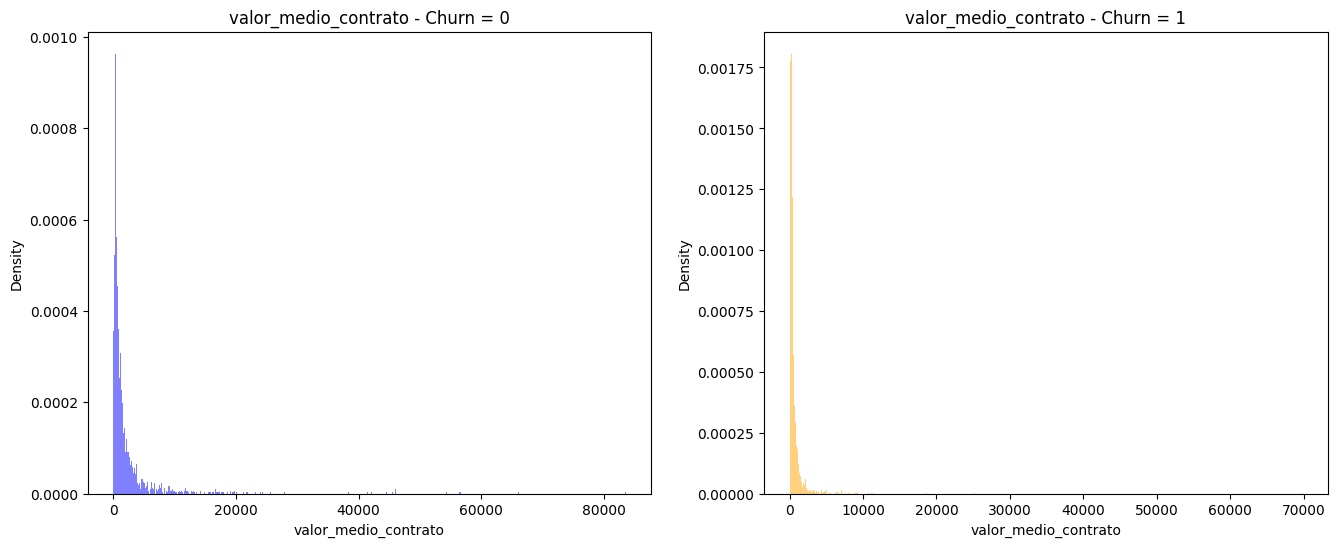

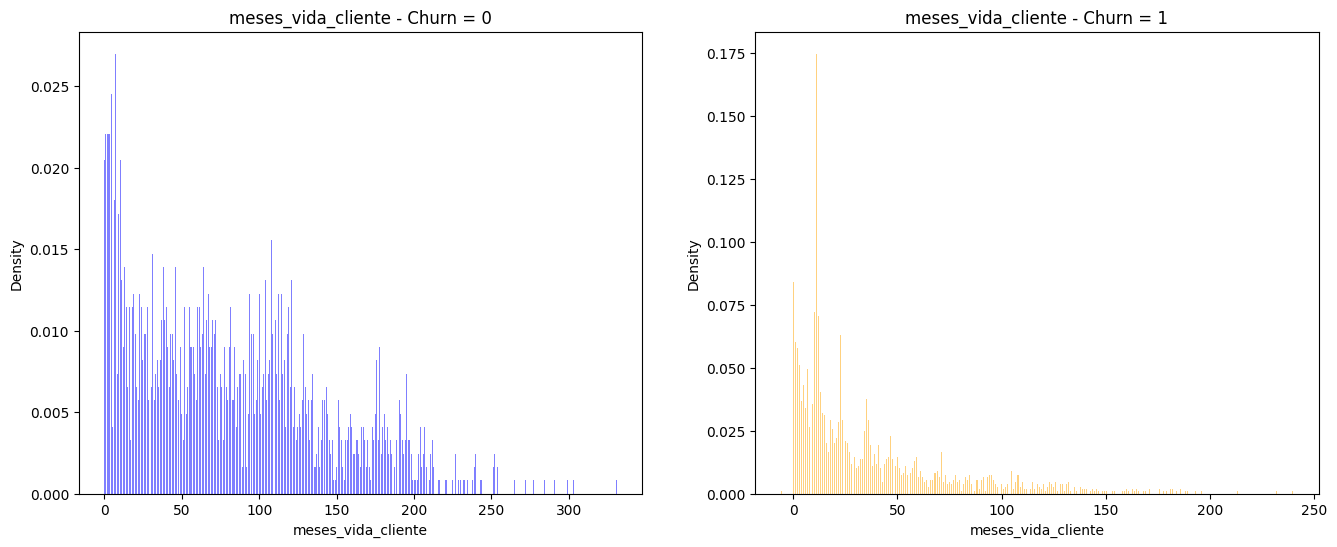

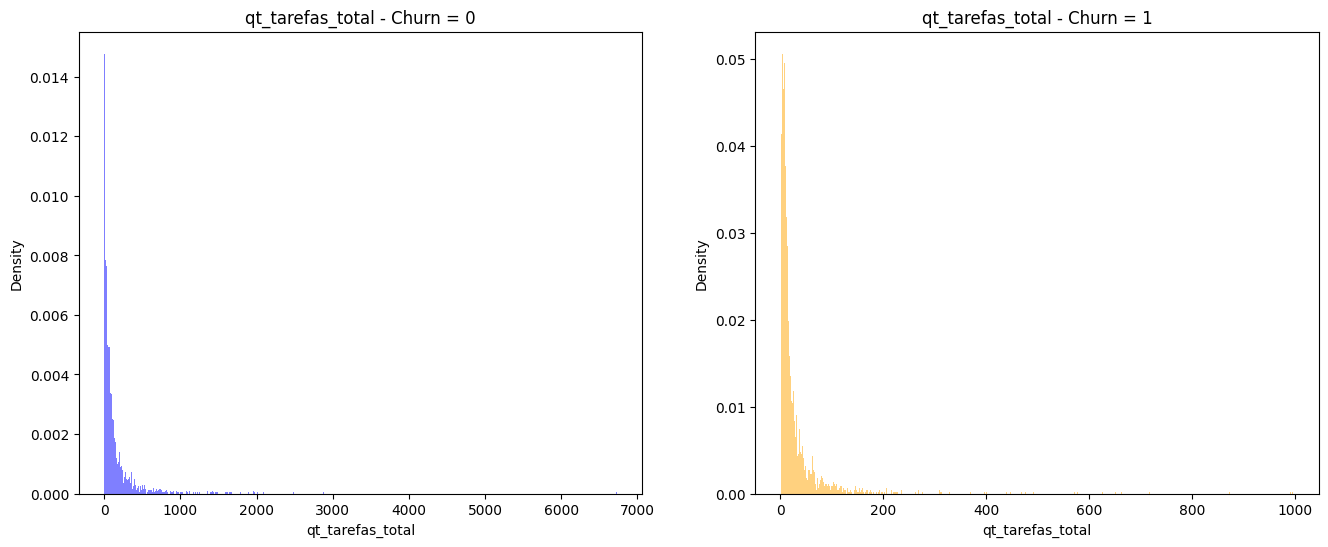

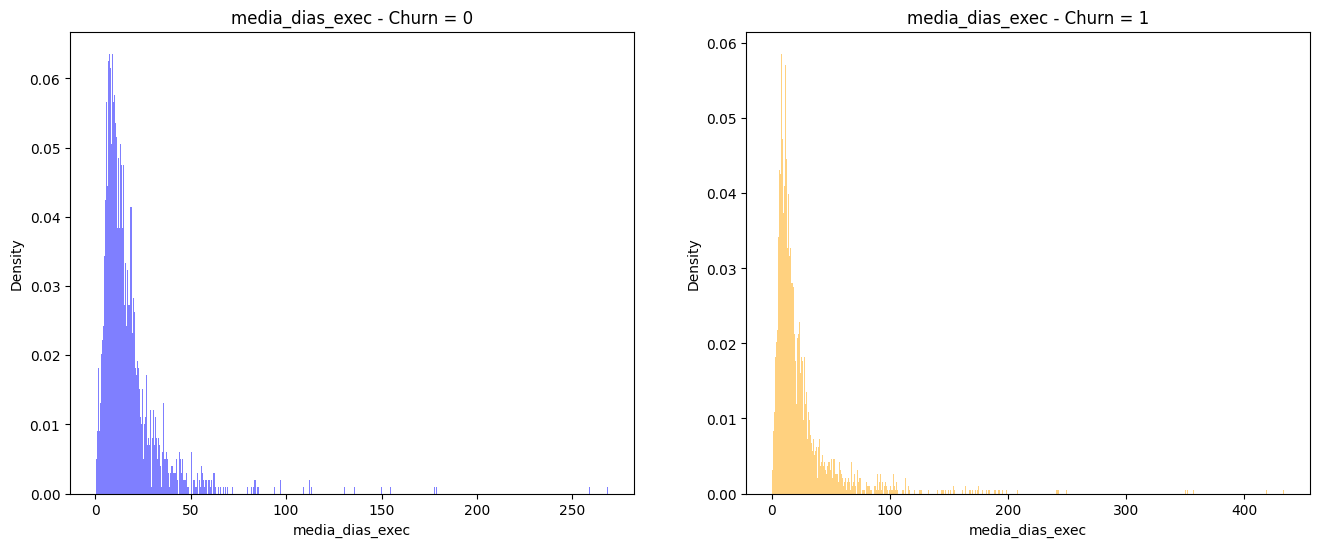

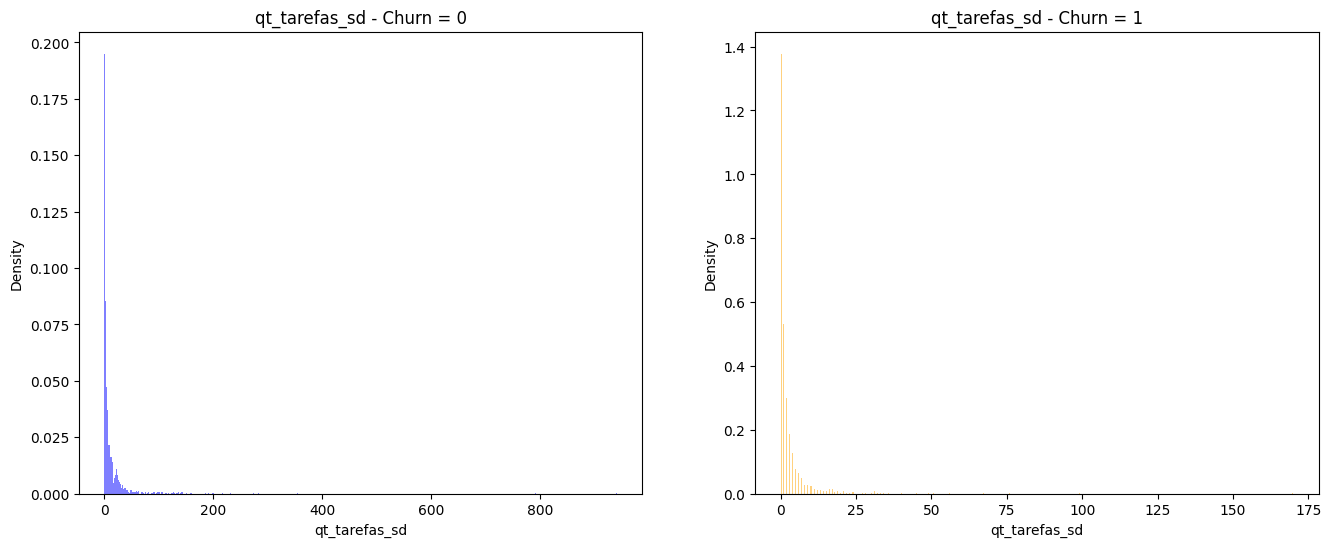

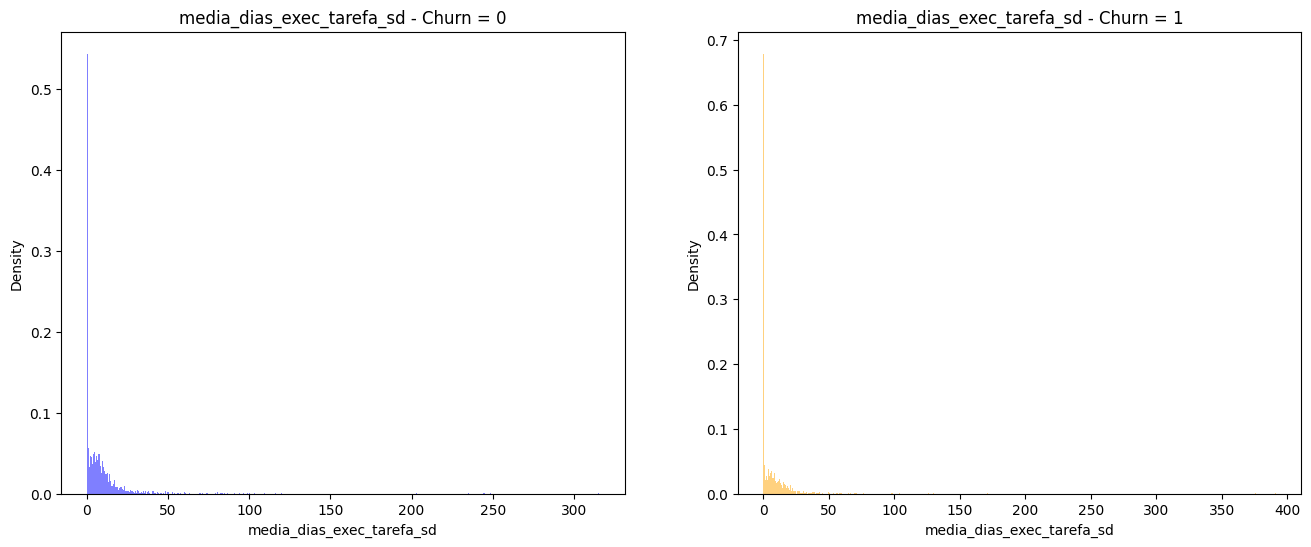

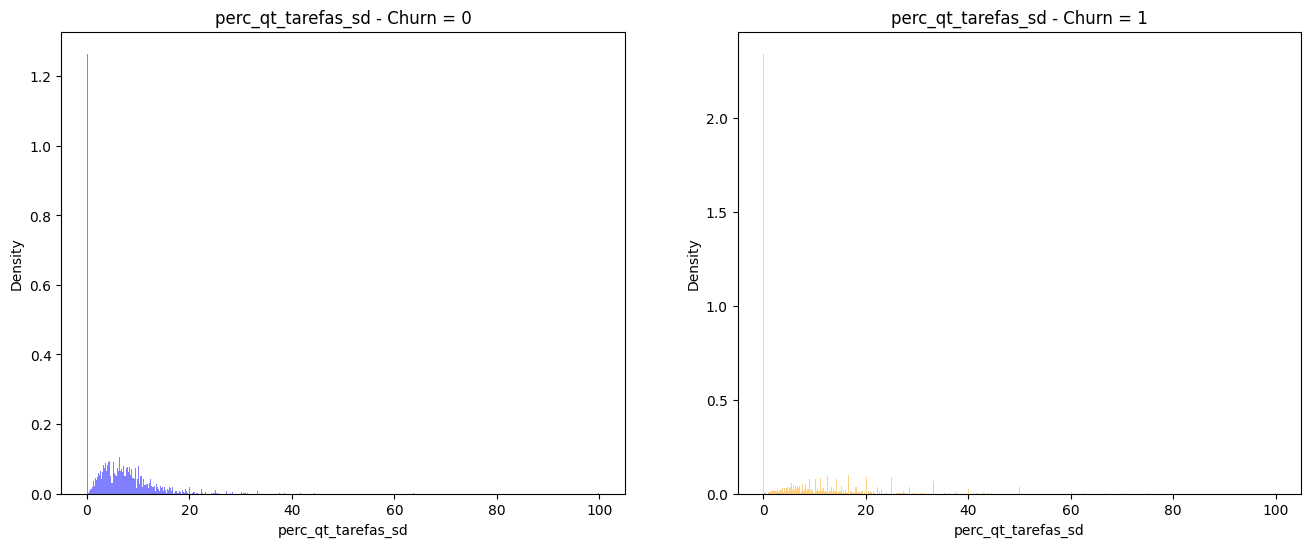

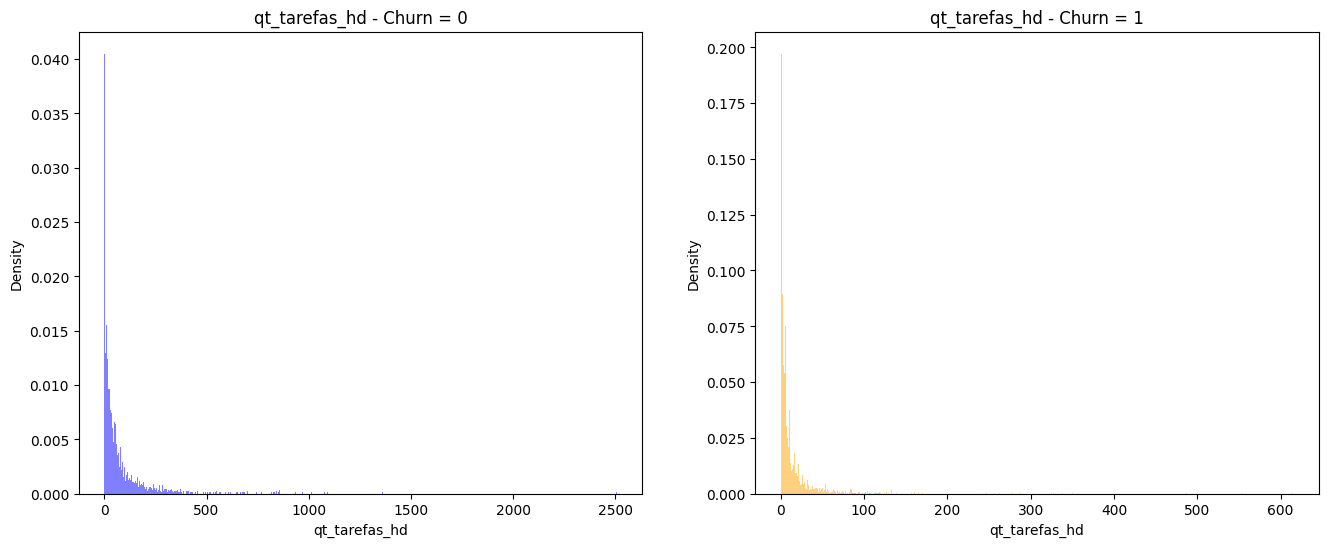

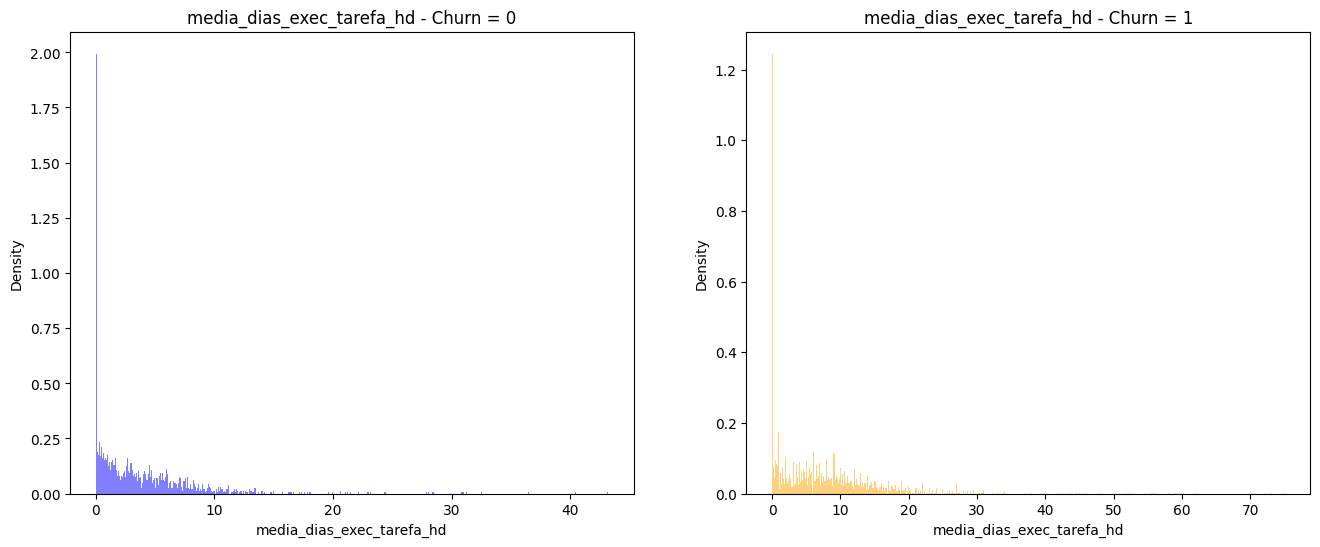

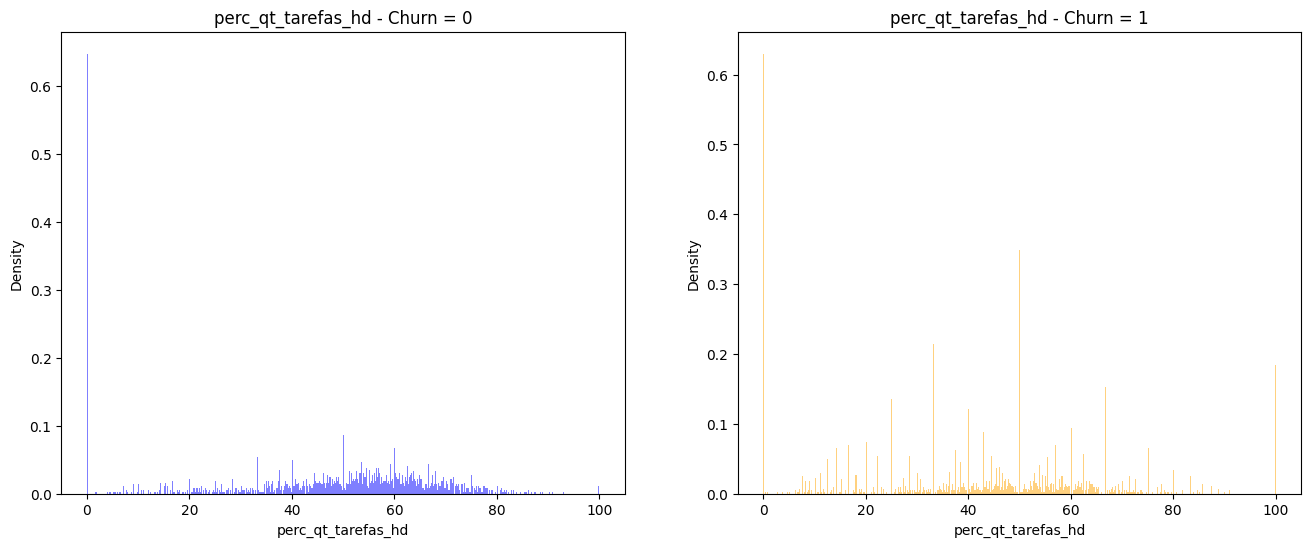

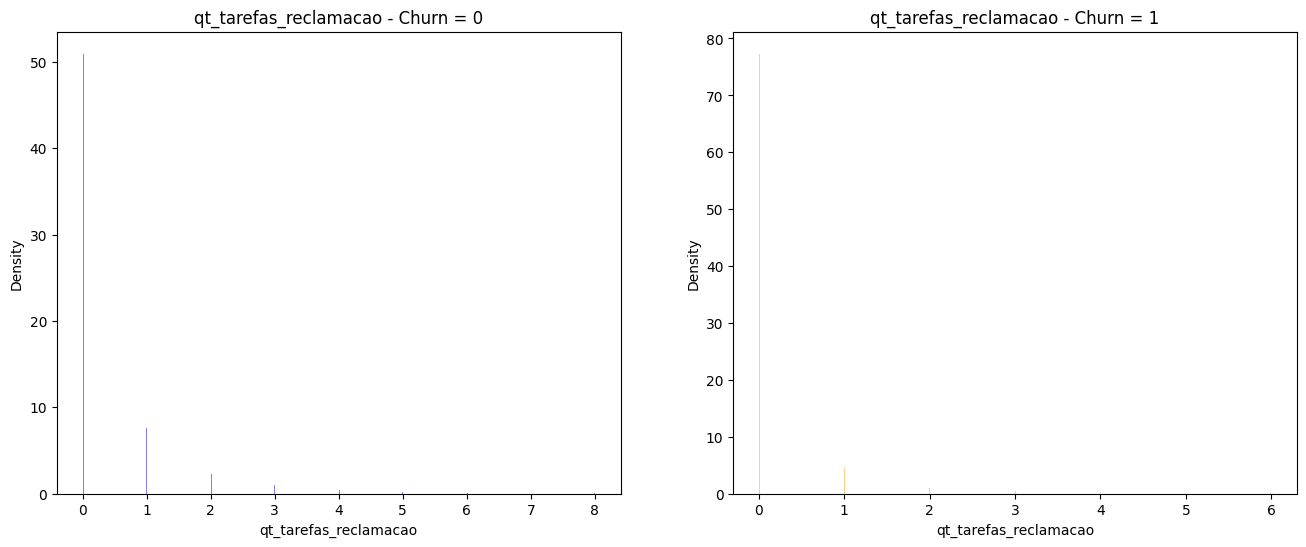

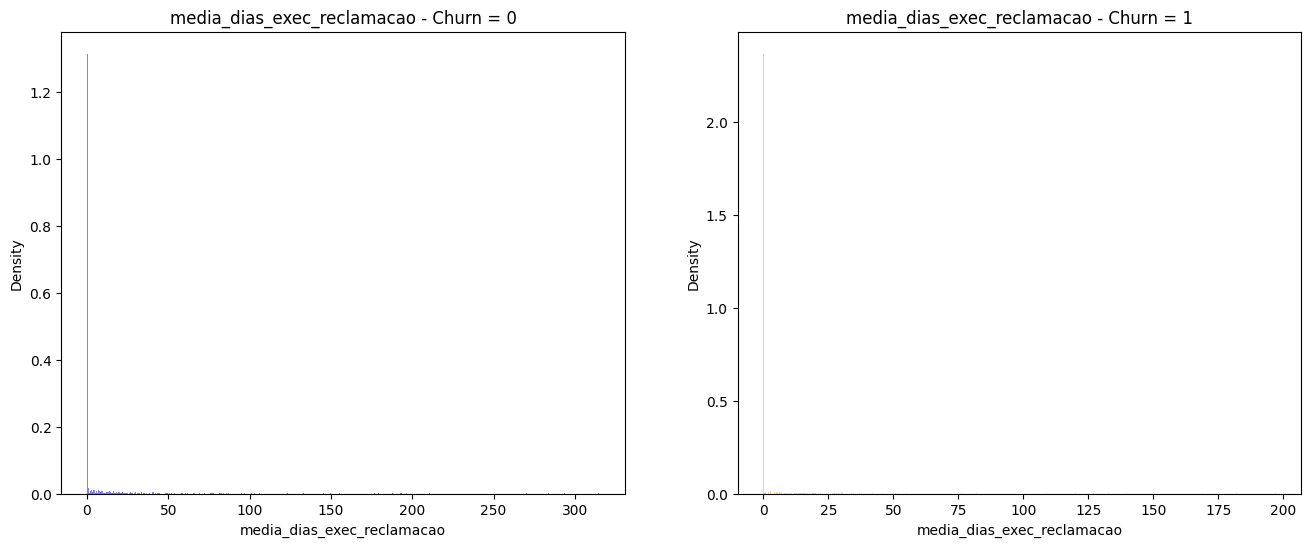

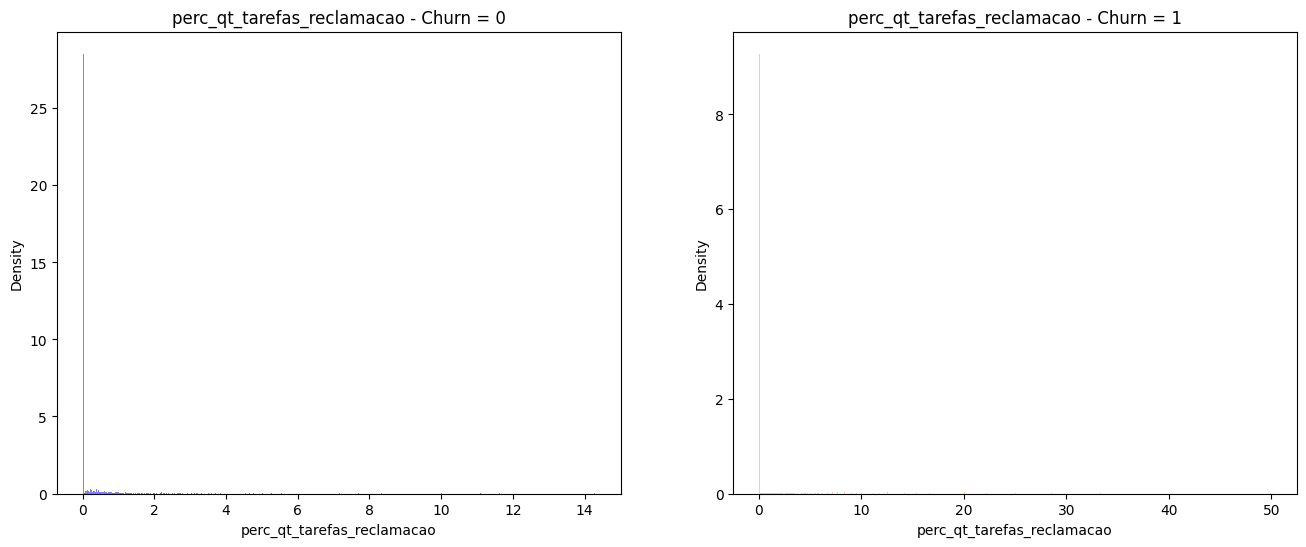

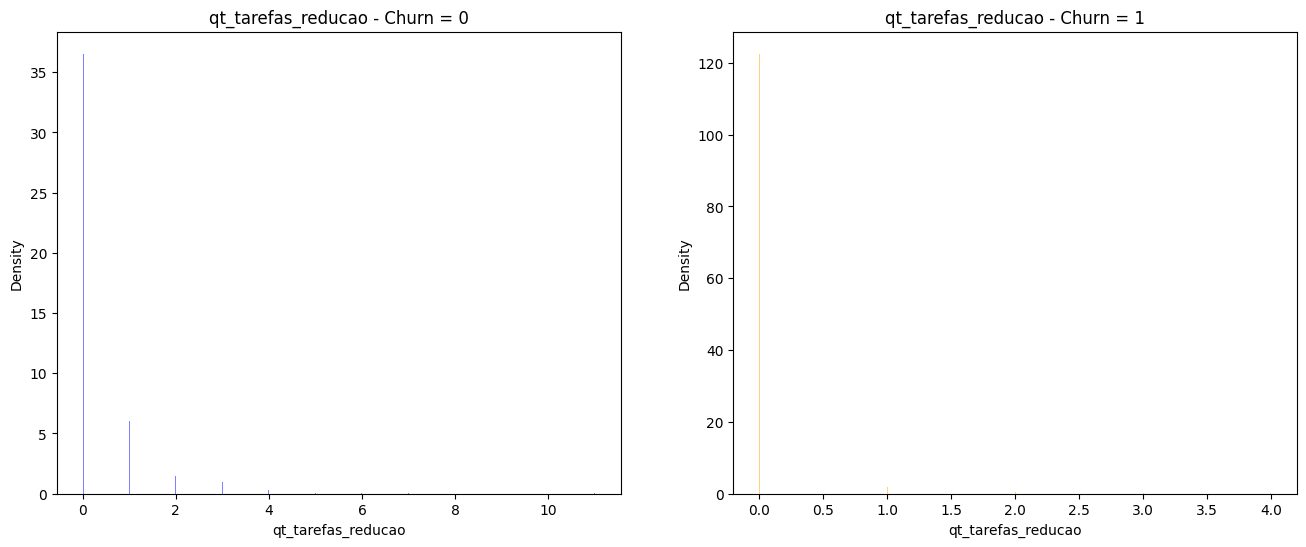

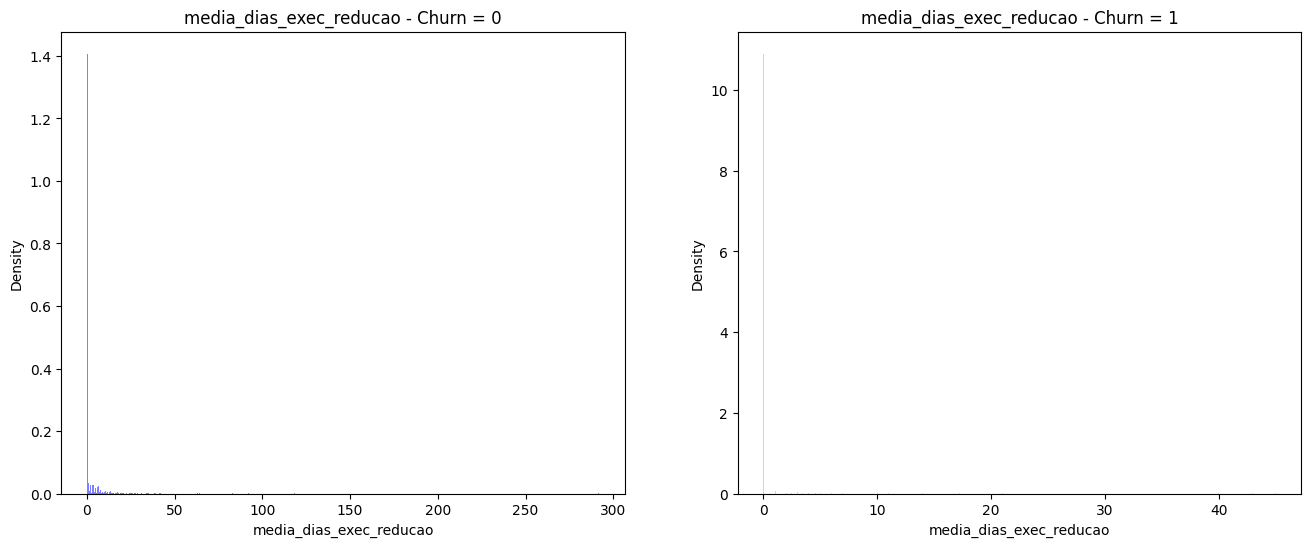

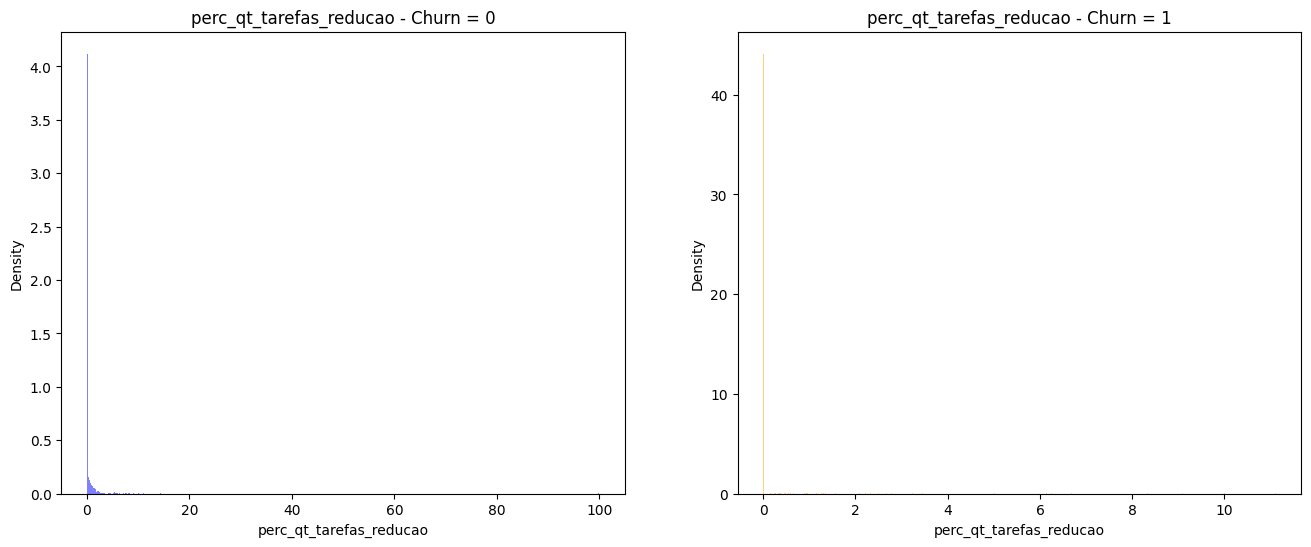

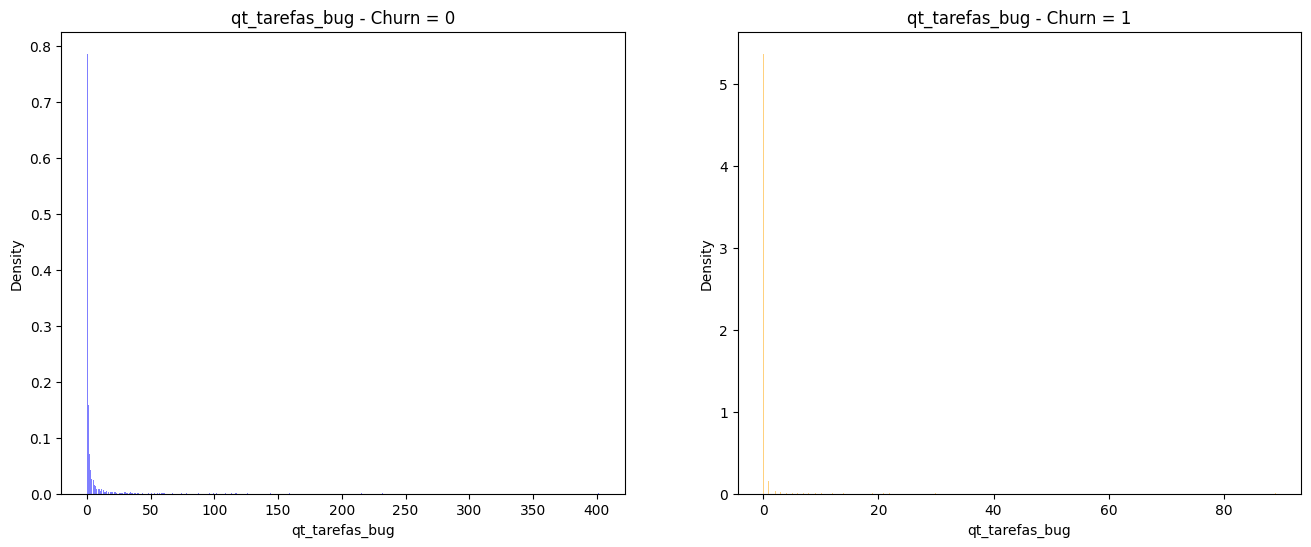

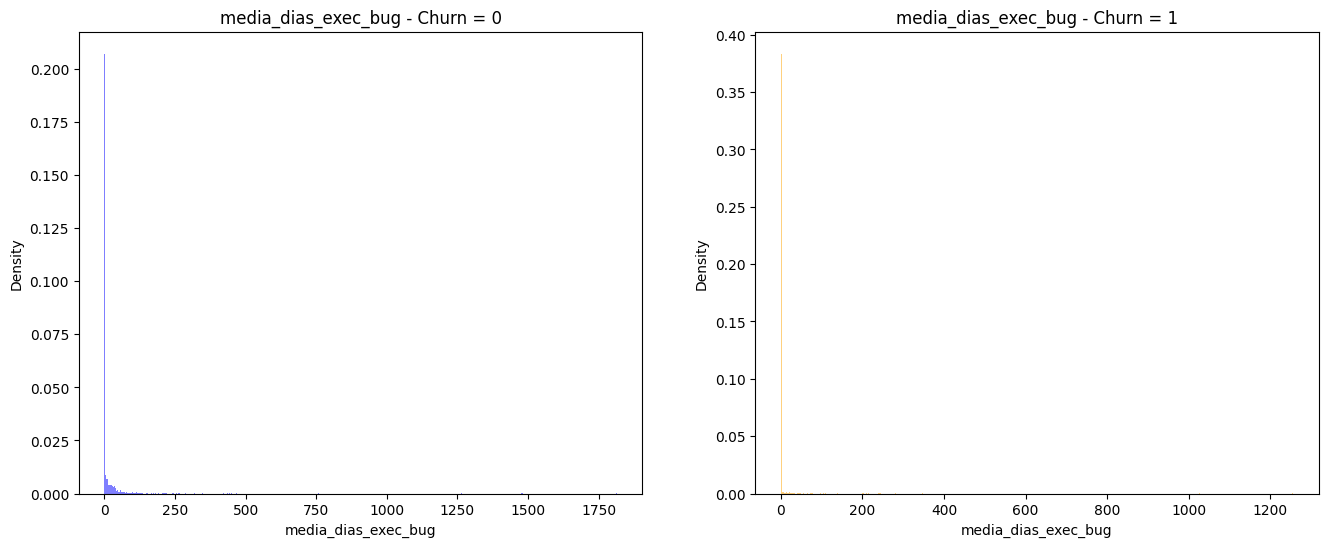

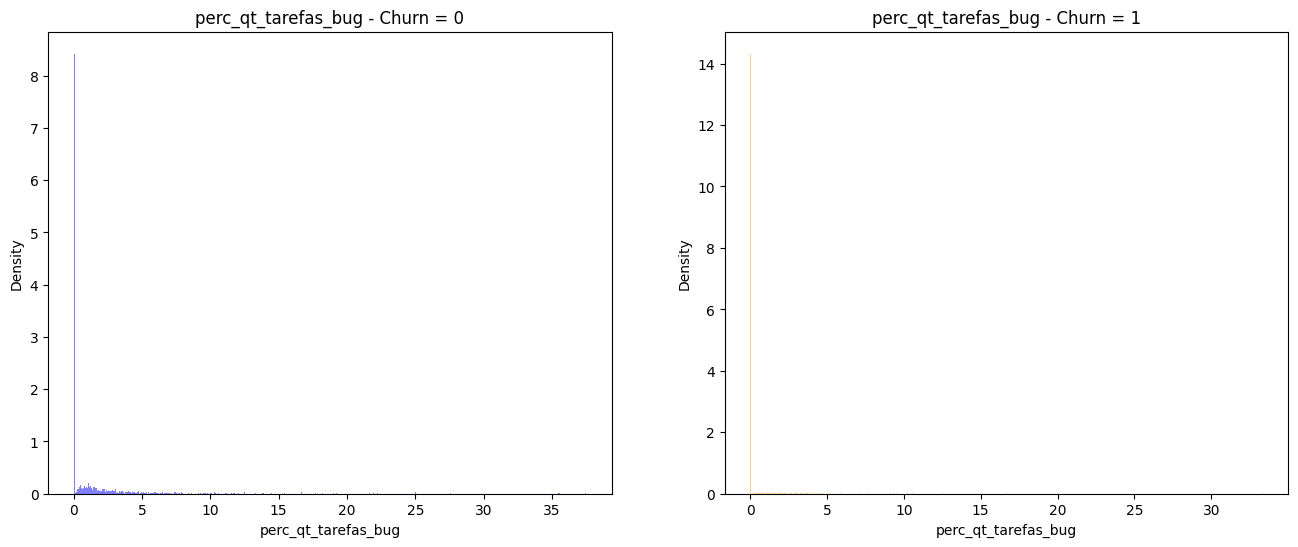

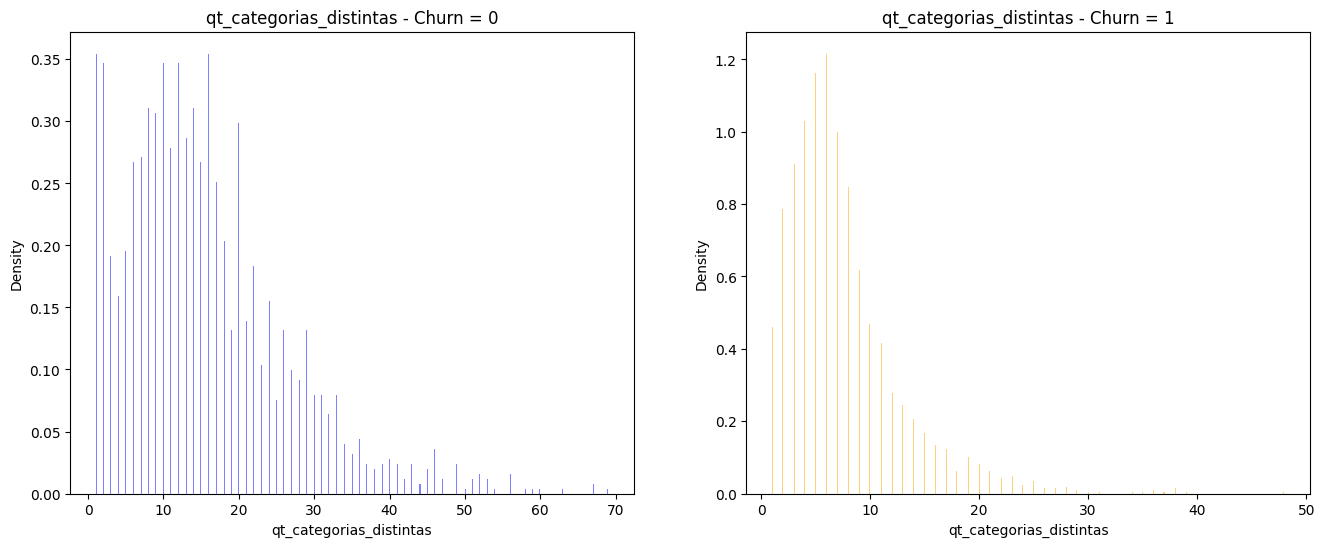

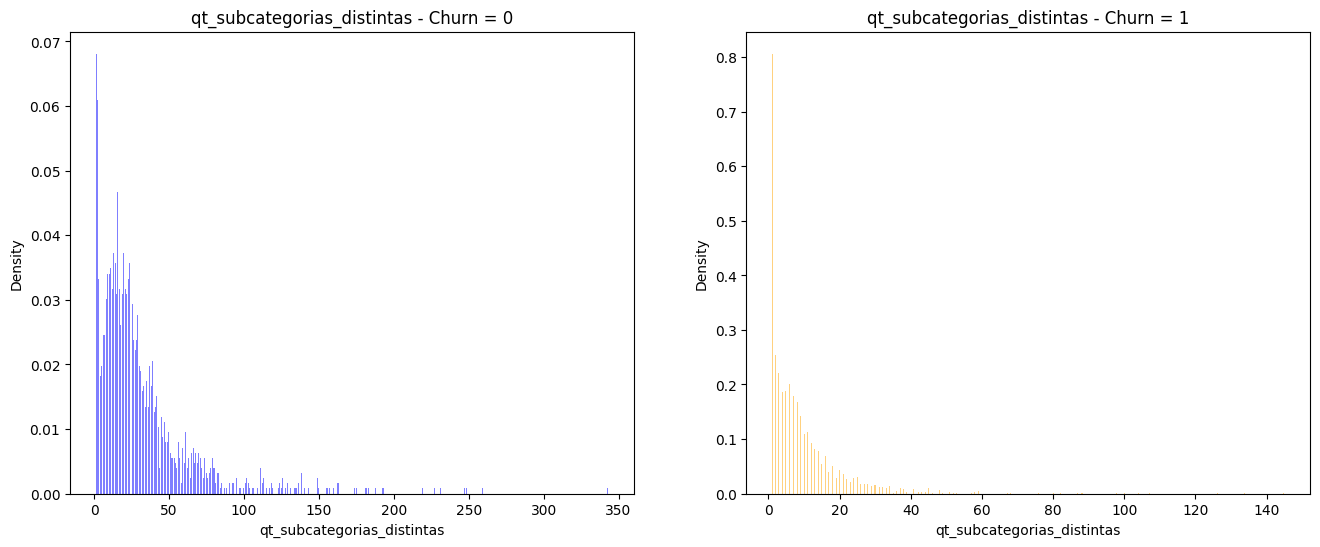

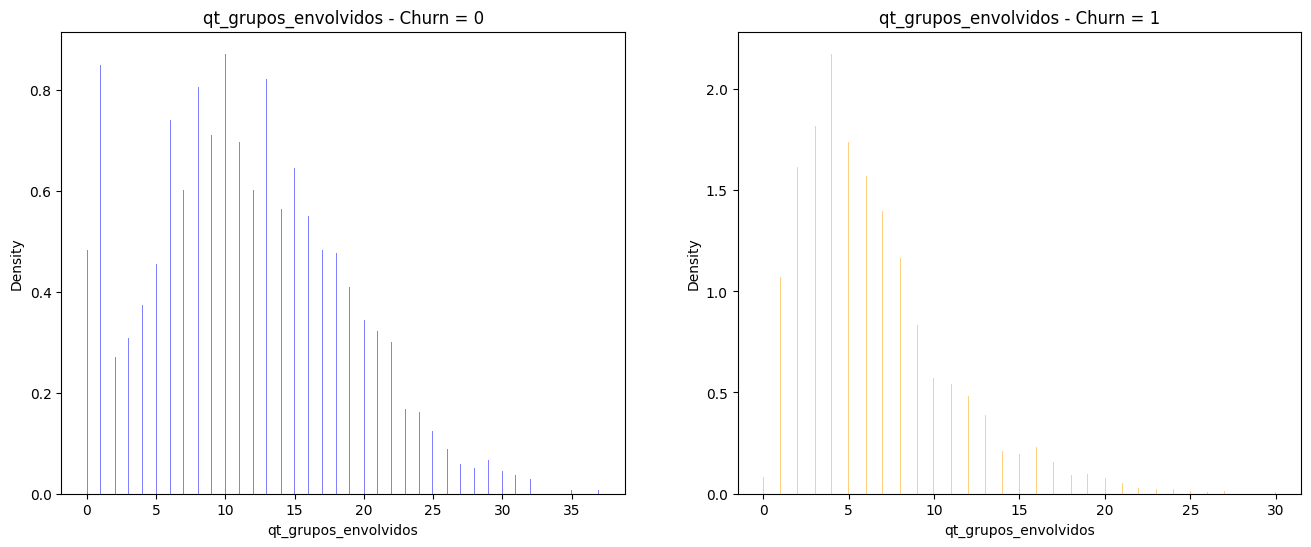

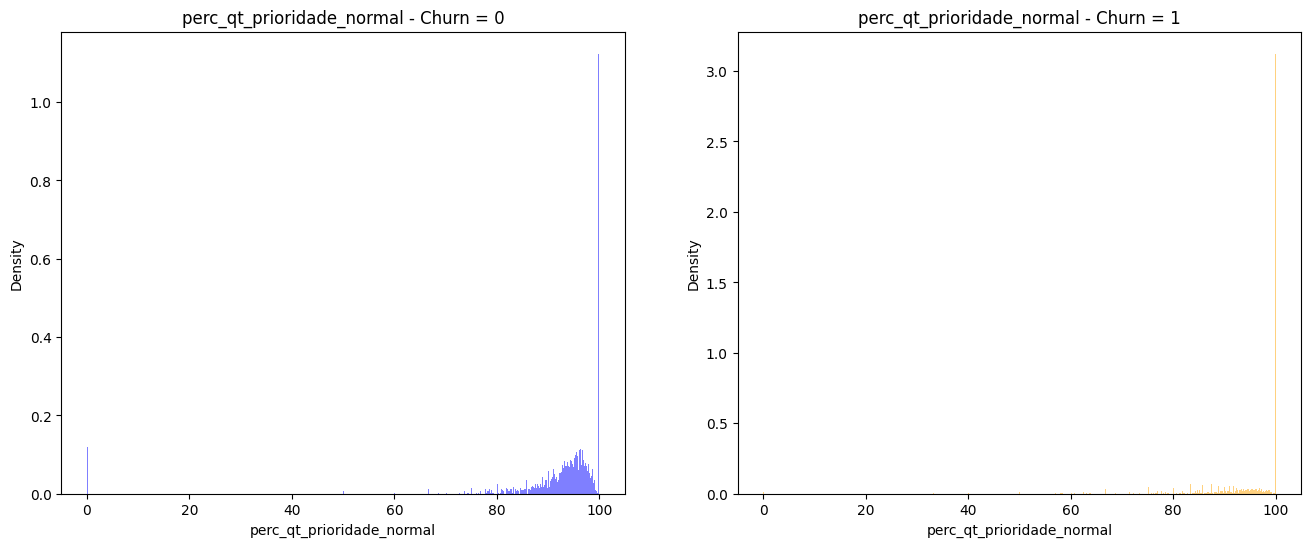

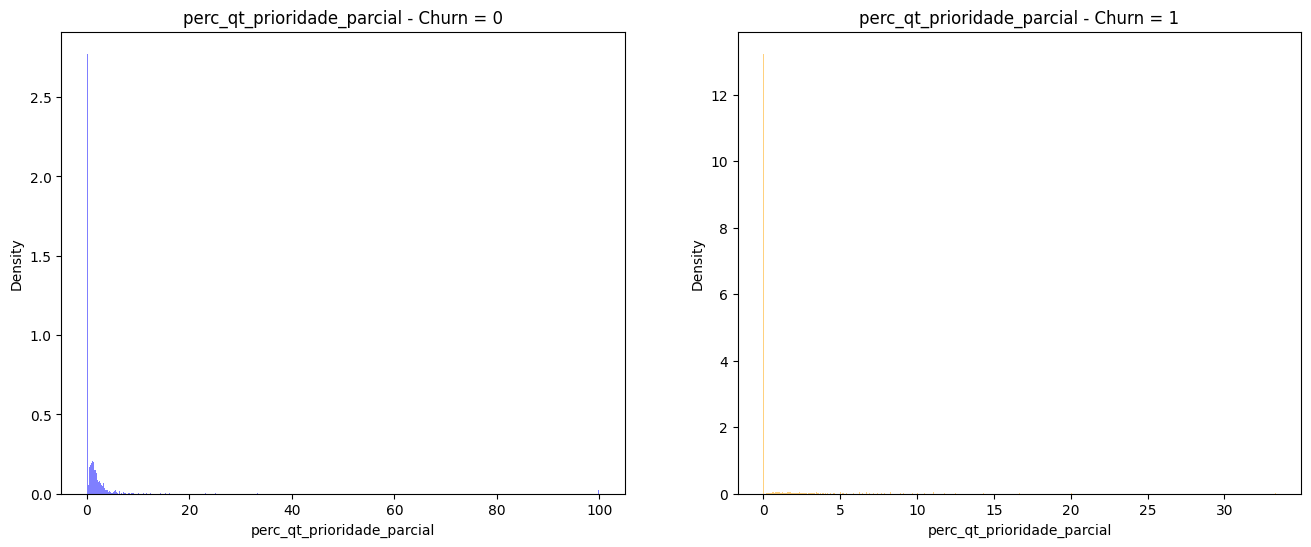

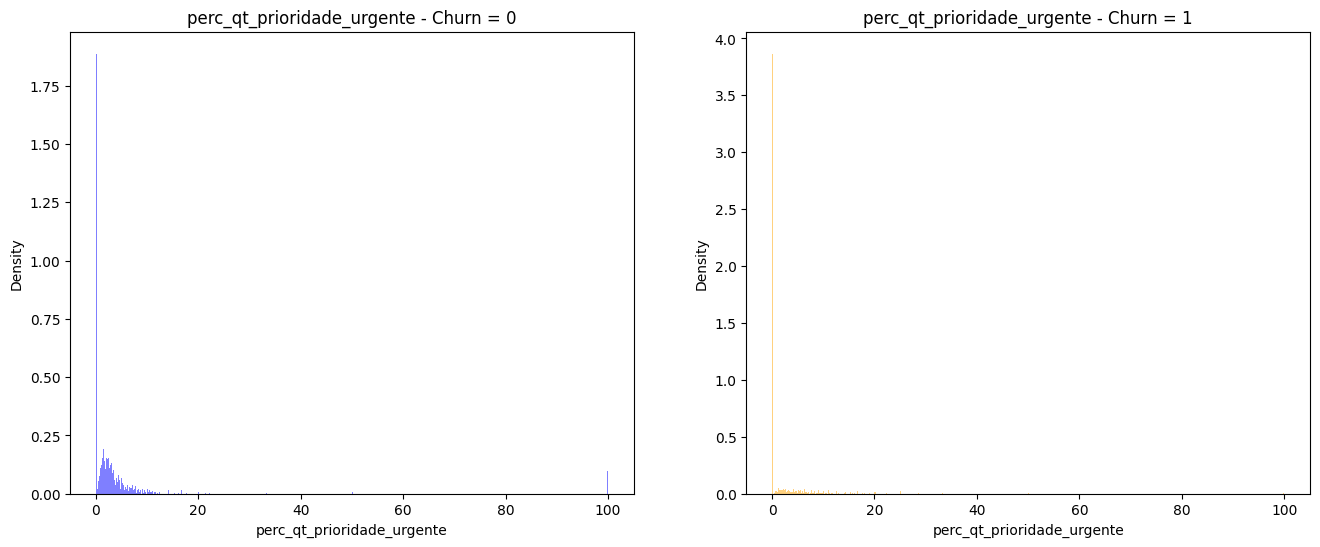

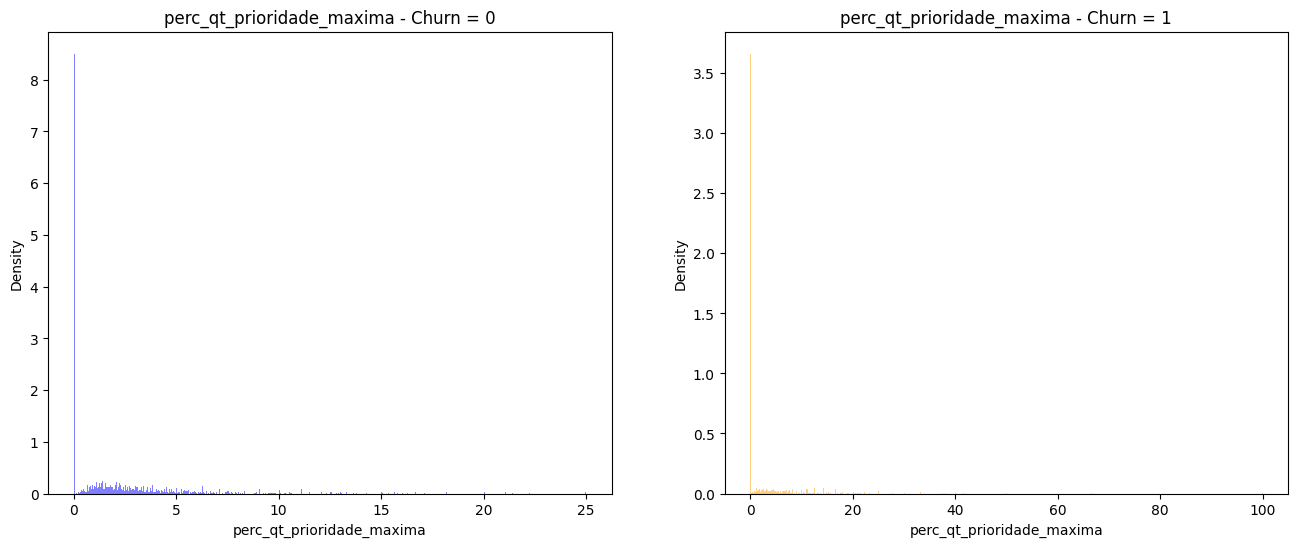

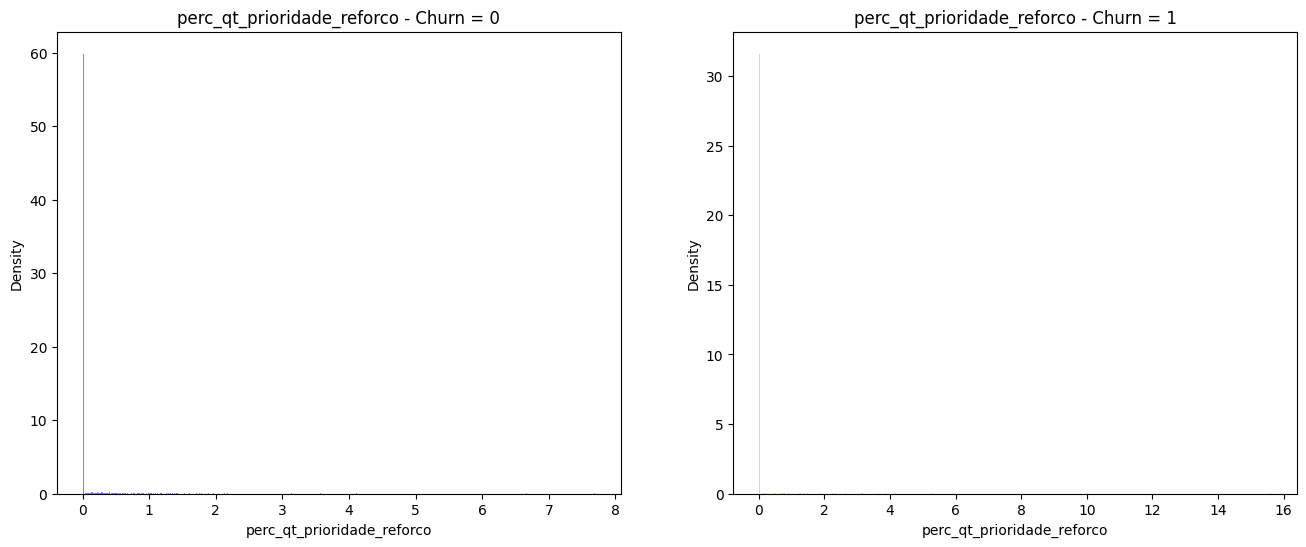

In [10]:
for col in dataset.drop(columns=['churn', 'cod_cliente']).columns:
    churn_0 = dataset[dataset['churn'] == 0][col]
    churn_1 = dataset[dataset['churn'] == 1][col]

    # Create histograms for each group
    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)
    plt.hist(churn_0, bins=500, alpha=0.5, label='Churn = 0', color='blue', density=True)
    plt.title(f'{col} - Churn = 0')
    plt.xlabel(col)
    plt.ylabel('Density')

    plt.subplot(1, 2, 2)
    plt.hist(churn_1, bins=500, alpha=0.5, label='Churn = 1', color='orange', density=True)
    plt.title(f'{col} - Churn = 1')
    plt.xlabel(col)
    plt.ylabel('Density')

    plt.show()

## Distribuição do Tempo de Casa por Status de Churn

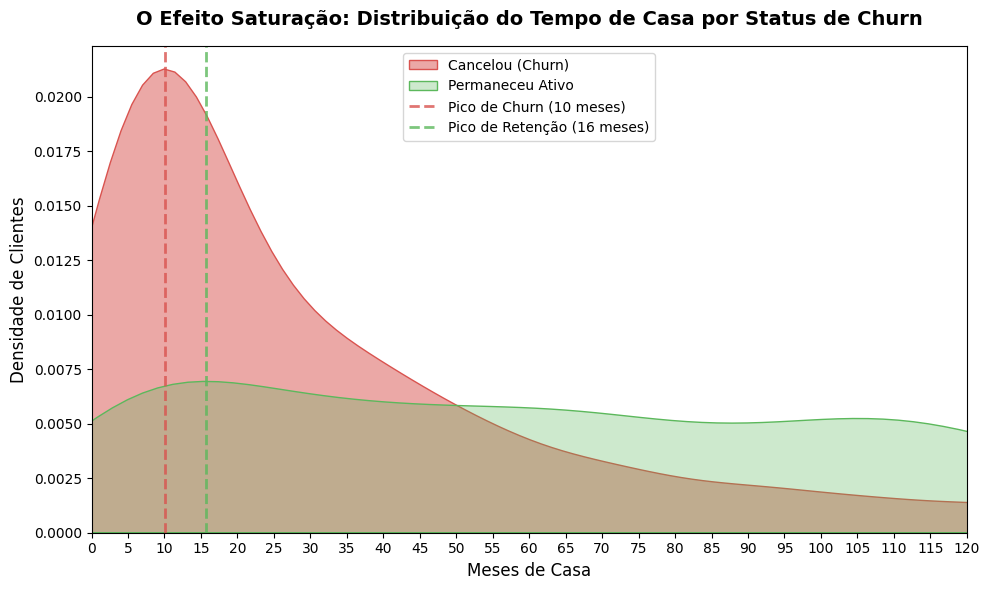

In [11]:
# Filtra os dados de cada grupo isolando os meses de casa
ativos = dataset[dataset['churn'] == 0]['meses_vida_cliente']
churns = dataset[dataset['churn'] == 1]['meses_vida_cliente']

# Grid de meses para o cálculo (0 a 120 meses)
valores_x = np.linspace(0, 120, 1000)

# CÁLCULO DO PICO DA CURVA VERDE (ATIVOS)
estimador_verde = gaussian_kde(ativos)
densidade_verde = estimador_verde(valores_x)
pico_verde      = valores_x[np.argmax(densidade_verde)]

# CÁLCULO DO PICO DA CURVA VERMELHA (CHURN)
estimador_vermelho = gaussian_kde(churns)
densidade_vermelha = estimador_vermelho(valores_x)
pico_vermelho      = valores_x[np.argmax(densidade_vermelha)]

# PLOTAGEM DO GRÁFICO
plt.figure(figsize=(10, 6))

# Filtra e plota a distribuição do tempo de casa para os dois grupos
sns.kdeplot(data=dataset[dataset['churn'] == 1],
            x='meses_vida_cliente',
            label='Cancelou (Churn)',
            fill=True,
            color='#d9534f',
            alpha=0.5)

sns.kdeplot(data=dataset[dataset['churn'] == 0],
            x='meses_vida_cliente',
            label='Permaneceu Ativo',
            fill=True,
            color='#5cb85c',
            alpha=0.3)

plt.title('O Efeito Saturação: Distribuição do Tempo de Casa por Status de Churn',
          fontsize=14,
          fontweight='bold',
          pad=15)
plt.xlabel('Meses de Casa', fontsize=12)
plt.ylabel('Densidade de Clientes', fontsize=12)
plt.xlim(0, 120)
plt.xticks(np.arange(0, 121, step=5))

# LINHAS VERTICAIS DOS PICOS
# Linha do Churn (Vermelha)
plt.axvline(pico_vermelho,
            color='#d9534f',
            linestyle='--',
            linewidth=2,
            alpha=0.8,
            label=f'Pico de Churn ({pico_vermelho:.0f} meses)')

# Linha dos Ativos (Verde)
plt.axvline(pico_verde,
            color='#5cb85c',
            linestyle='--',
            linewidth=2,
            alpha=0.8,
            label=f'Pico de Retenção ({pico_verde:.0f} meses)')

plt.legend(loc='upper center', fontsize=10)
plt.tight_layout()
plt.show()

# Features

In [12]:
X = dataset.drop(['cod_cliente', 'churn'], axis=1)
X

,valor_medio_contrato,meses_vida_cliente,qt_tarefas_total,media_dias_exec,qt_tarefas_sd,media_dias_exec_tarefa_sd,perc_qt_tarefas_sd,qt_tarefas_hd,media_dias_exec_tarefa_hd,perc_qt_tarefas_hd,...,media_dias_exec_bug,perc_qt_tarefas_bug,qt_categorias_distintas,qt_subcategorias_distintas,qt_grupos_envolvidos,perc_qt_prioridade_normal,perc_qt_prioridade_parcial,perc_qt_prioridade_urgente,perc_qt_prioridade_maxima,perc_qt_prioridade_reforco
0,1037.88,26,476,0.0840,0,0.0,0.0,0,0.0000,0.00000,...,0.0,0.0,3,6,3,100.00000,0.00000,0.00000,0.0,0.0
1,0.00,37,15,0.2667,0,0.0,0.0,11,0.3636,73.33333,...,0.0,0.0,4,7,4,80.00000,0.00000,20.00000,0.0,0.0
2,468.06,20,3,0.3333,0,0.0,0.0,0,0.0000,0.00000,...,0.0,0.0,3,3,1,66.66667,33.33333,0.00000,0.0,0.0
3,300.00,0,3,0.3333,0,0.0,0.0,0,0.0000,0.00000,...,0.0,0.0,3,3,1,100.00000,0.00000,0.00000,0.0,0.0
4,332.01,12,3,0.3333,0,0.0,0.0,0,0.0000,0.00000,...,0.0,0.0,3,3,0,100.00000,0.00000,0.00000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4063,601.73,11,12,349.9167,0,0.0,0.0,1,0.0000,8.33333,...,0.0,0.0,7,9,5,91.66667,0.00000,8.33333,0.0,0.0
4064,40.00,1,3,352.3333,0,0.0,0.0,0,0.0000,0.00000,...,0.0,0.0,3,3,2,100.00000,0.00000,0.00000,0.0,0.0
4065,1051.78,15,1,357.0000,0,0.0,0.0,0,0.0000,0.00000,...,0.0,0.0,1,1,1,100.00000,0.00000,0.00000,0.0,0.0
4066,79.00,11,4,419.0000,0,0.0,0.0,1,27.0000,25.00000,...,0.0,0.0,2,2,4,100.00000,0.00000,0.00000,0.0,0.0


In [13]:
y = dataset['churn']

In [14]:
# Verificação de balanceamento da terget
total_clientes              = y.value_counts().sum()
total_clientes_churn        = y[y == 1].count()
total_clientes_nao_churn    = y[y == 0].count()

print(f'Total de clientes:                      {total_clientes}')
print(f'Porcentagem de clientes que não churn:  {total_clientes_nao_churn   / total_clientes * 100:.2f}%')
print(f'Porcentagem de clientes que churn:      {total_clientes_churn       / total_clientes * 100:.2f}%')

Total de clientes:                      4068
Porcentagem de clientes que não churn:  45.38%
Porcentagem de clientes que churn:      54.62%


# Análise de Correlação e Multicolinearidade

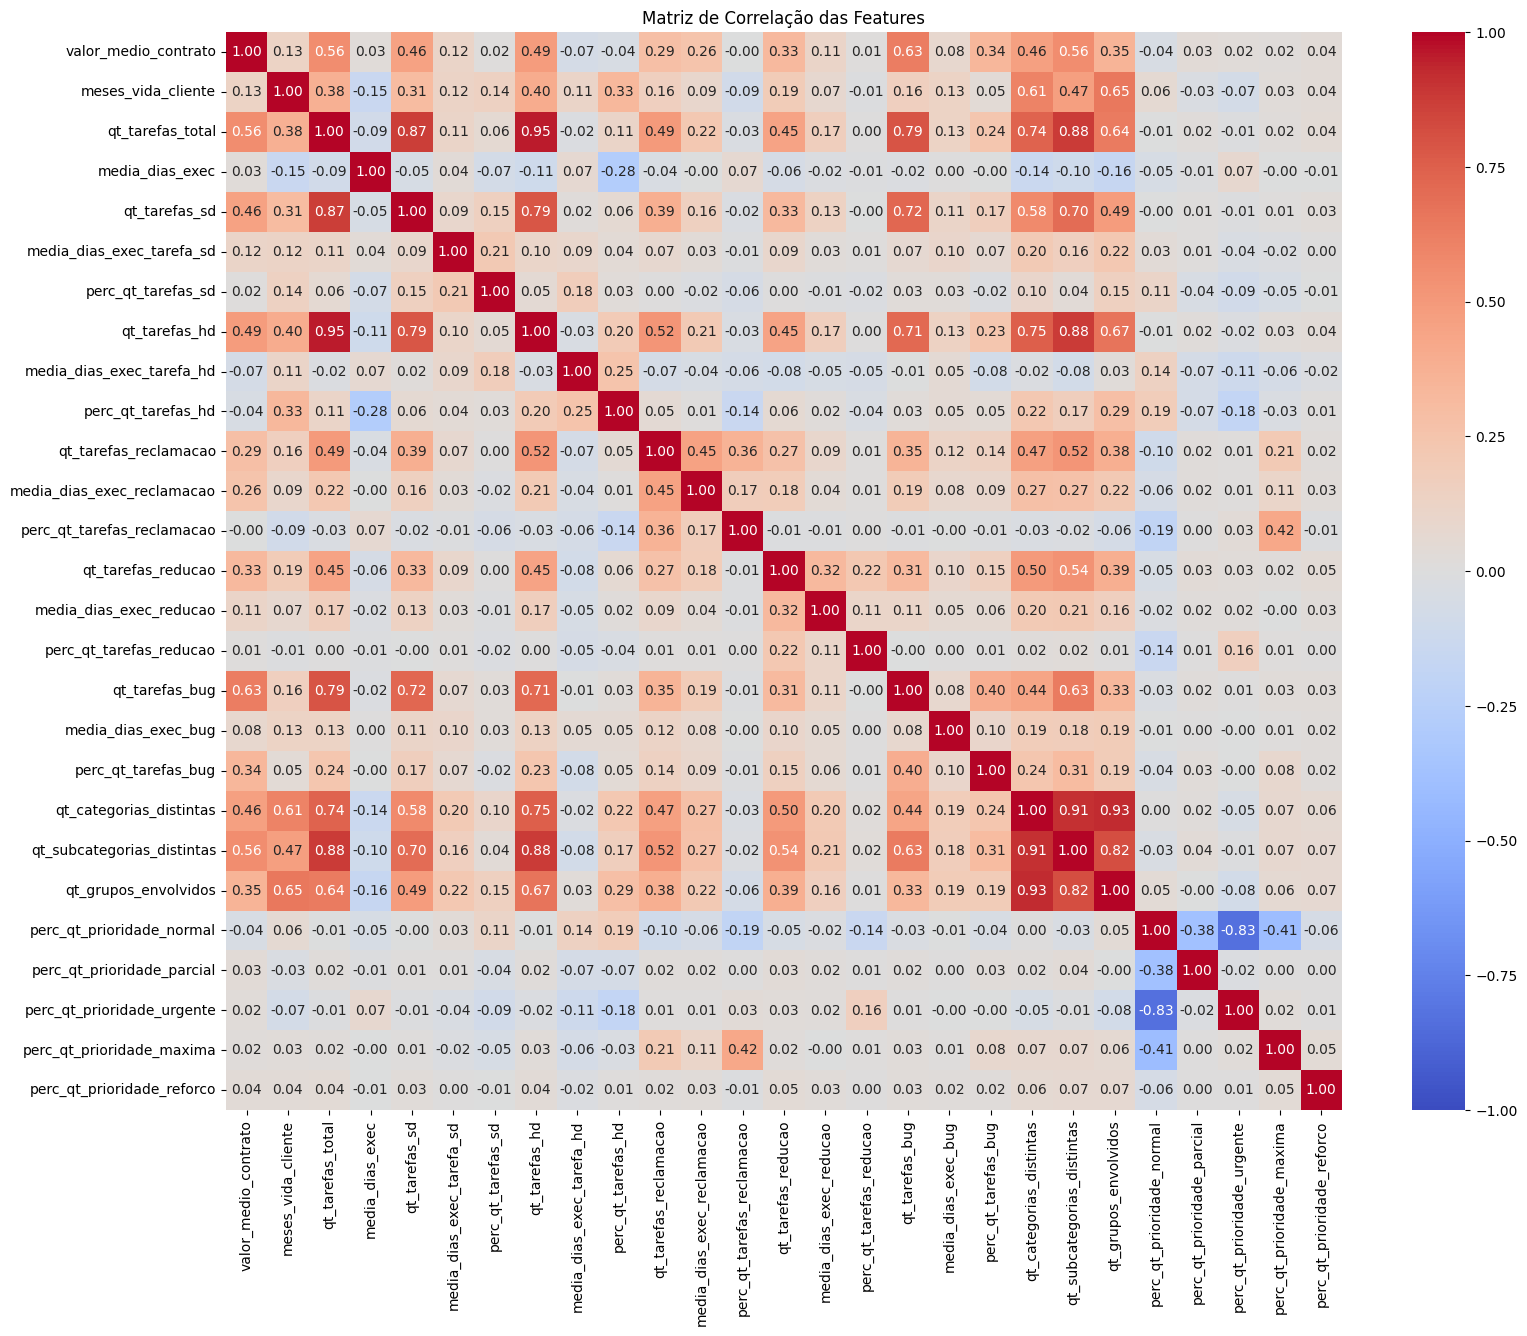

In [15]:
# Calculando a matriz de correlação de Pearson
plt.figure(figsize=(18, 14))
matrix_corr = X.corr()

# Plotando o Heatmap
sns.heatmap(matrix_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação das Features")
plt.show()

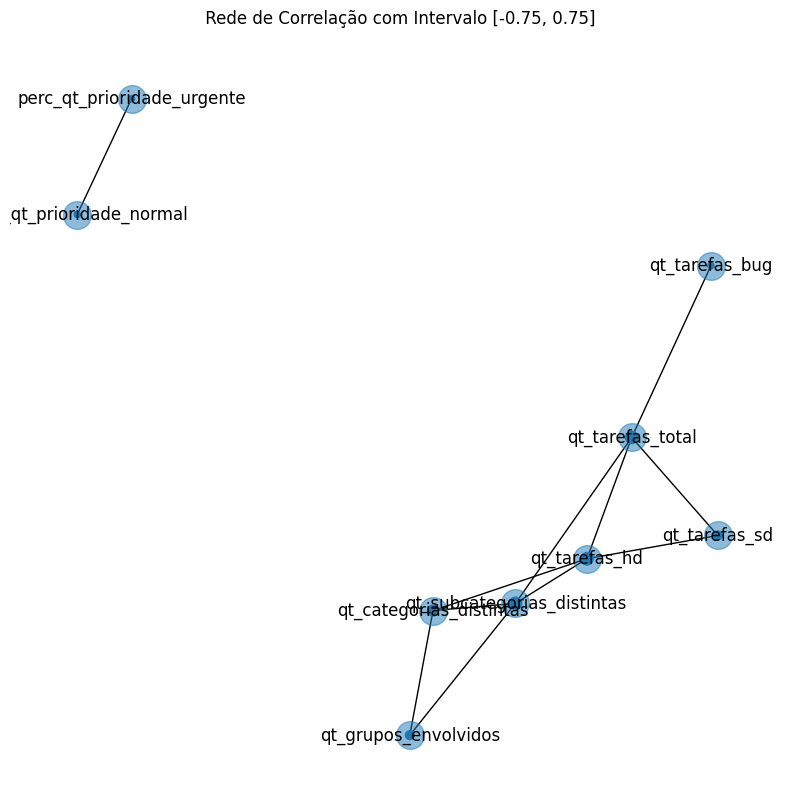

In [16]:
network_corr(X, matrix_corr, corr_interval=[-0.75, 0.75])

In [17]:
# Filtrando correlações altas
upper_tri = matrix_corr.where(np.triu(np.ones(matrix_corr.shape), k=1).astype(bool))
colunas_alta_corr = [column for column in upper_tri.columns if any(abs(upper_tri[column]) >= 0.75)]
print(f"Sugestão de variáveis para exclusão por alta correlação:\n{colunas_alta_corr}")

Sugestão de variáveis para exclusão por alta correlação:
['qt_tarefas_sd', 'qt_tarefas_hd', 'qt_tarefas_bug', 'qt_categorias_distintas', 'qt_subcategorias_distintas', 'qt_grupos_envolvidos', 'perc_qt_prioridade_urgente']


# Features Descartadas

In [18]:
# Verificação das colunas com zero inflation
total_linhas = X.shape[0]

colunas_zeros = {}
remove_colunas_zeros = []
for col in X.columns:
    linhas_zero = X[X[col] == 0][col].count()
    proporcao_zero = (linhas_zero / total_linhas).round(2)
    colunas_zeros[col] = proporcao_zero
    if proporcao_zero > 0.8:
        remove_colunas_zeros.append(col)

pd.DataFrame(list(colunas_zeros.items()),
    columns=['feature', 'proporcao_zeros']
    ).sort_values(by='proporcao_zeros', ascending=False).reset_index(drop=True)

,feature,proporcao_zeros
0,perc_qt_prioridade_reforco,0.96
1,media_dias_exec_reducao,0.91
2,perc_qt_tarefas_reducao,0.90
3,qt_tarefas_reducao,0.90
4,qt_tarefas_reclamacao,0.88
5,media_dias_exec_reclamacao,0.88
6,perc_qt_tarefas_reclamacao,0.88
7,media_dias_exec_bug,0.83
8,qt_tarefas_bug,0.81
9,perc_qt_tarefas_bug,0.81


In [19]:
remove_colunas_zeros

['qt_tarefas_reclamacao',
 'media_dias_exec_reclamacao',
 'perc_qt_tarefas_reclamacao',
 'qt_tarefas_reducao',
 'media_dias_exec_reducao',
 'perc_qt_tarefas_reducao',
 'qt_tarefas_bug',
 'media_dias_exec_bug',
 'perc_qt_tarefas_bug',
 'perc_qt_prioridade_reforco']

In [20]:
to_drop_completo = remove_colunas_zeros + colunas_alta_corr
to_drop_completo

['qt_tarefas_reclamacao',
 'media_dias_exec_reclamacao',
 'perc_qt_tarefas_reclamacao',
 'qt_tarefas_reducao',
 'media_dias_exec_reducao',
 'perc_qt_tarefas_reducao',
 'qt_tarefas_bug',
 'media_dias_exec_bug',
 'perc_qt_tarefas_bug',
 'perc_qt_prioridade_reforco',
 'qt_tarefas_sd',
 'qt_tarefas_hd',
 'qt_tarefas_bug',
 'qt_categorias_distintas',
 'qt_subcategorias_distintas',
 'qt_grupos_envolvidos',
 'perc_qt_prioridade_urgente']

In [21]:
X_limpo = X.drop(columns=to_drop_completo)
X_limpo.head()

,valor_medio_contrato,meses_vida_cliente,qt_tarefas_total,media_dias_exec,media_dias_exec_tarefa_sd,perc_qt_tarefas_sd,media_dias_exec_tarefa_hd,perc_qt_tarefas_hd,perc_qt_prioridade_normal,perc_qt_prioridade_parcial,perc_qt_prioridade_maxima
0,1037.88,26,476,0.0840,0.0,0.0,0.0000,0.00000,100.00000,0.00000,0.0
1,0.00,37,15,0.2667,0.0,0.0,0.3636,73.33333,80.00000,0.00000,0.0
2,468.06,20,3,0.3333,0.0,0.0,0.0000,0.00000,66.66667,33.33333,0.0
3,300.00,0,3,0.3333,0.0,0.0,0.0000,0.00000,100.00000,0.00000,0.0
4,332.01,12,3,0.3333,0.0,0.0,0.0000,0.00000,100.00000,0.00000,0.0


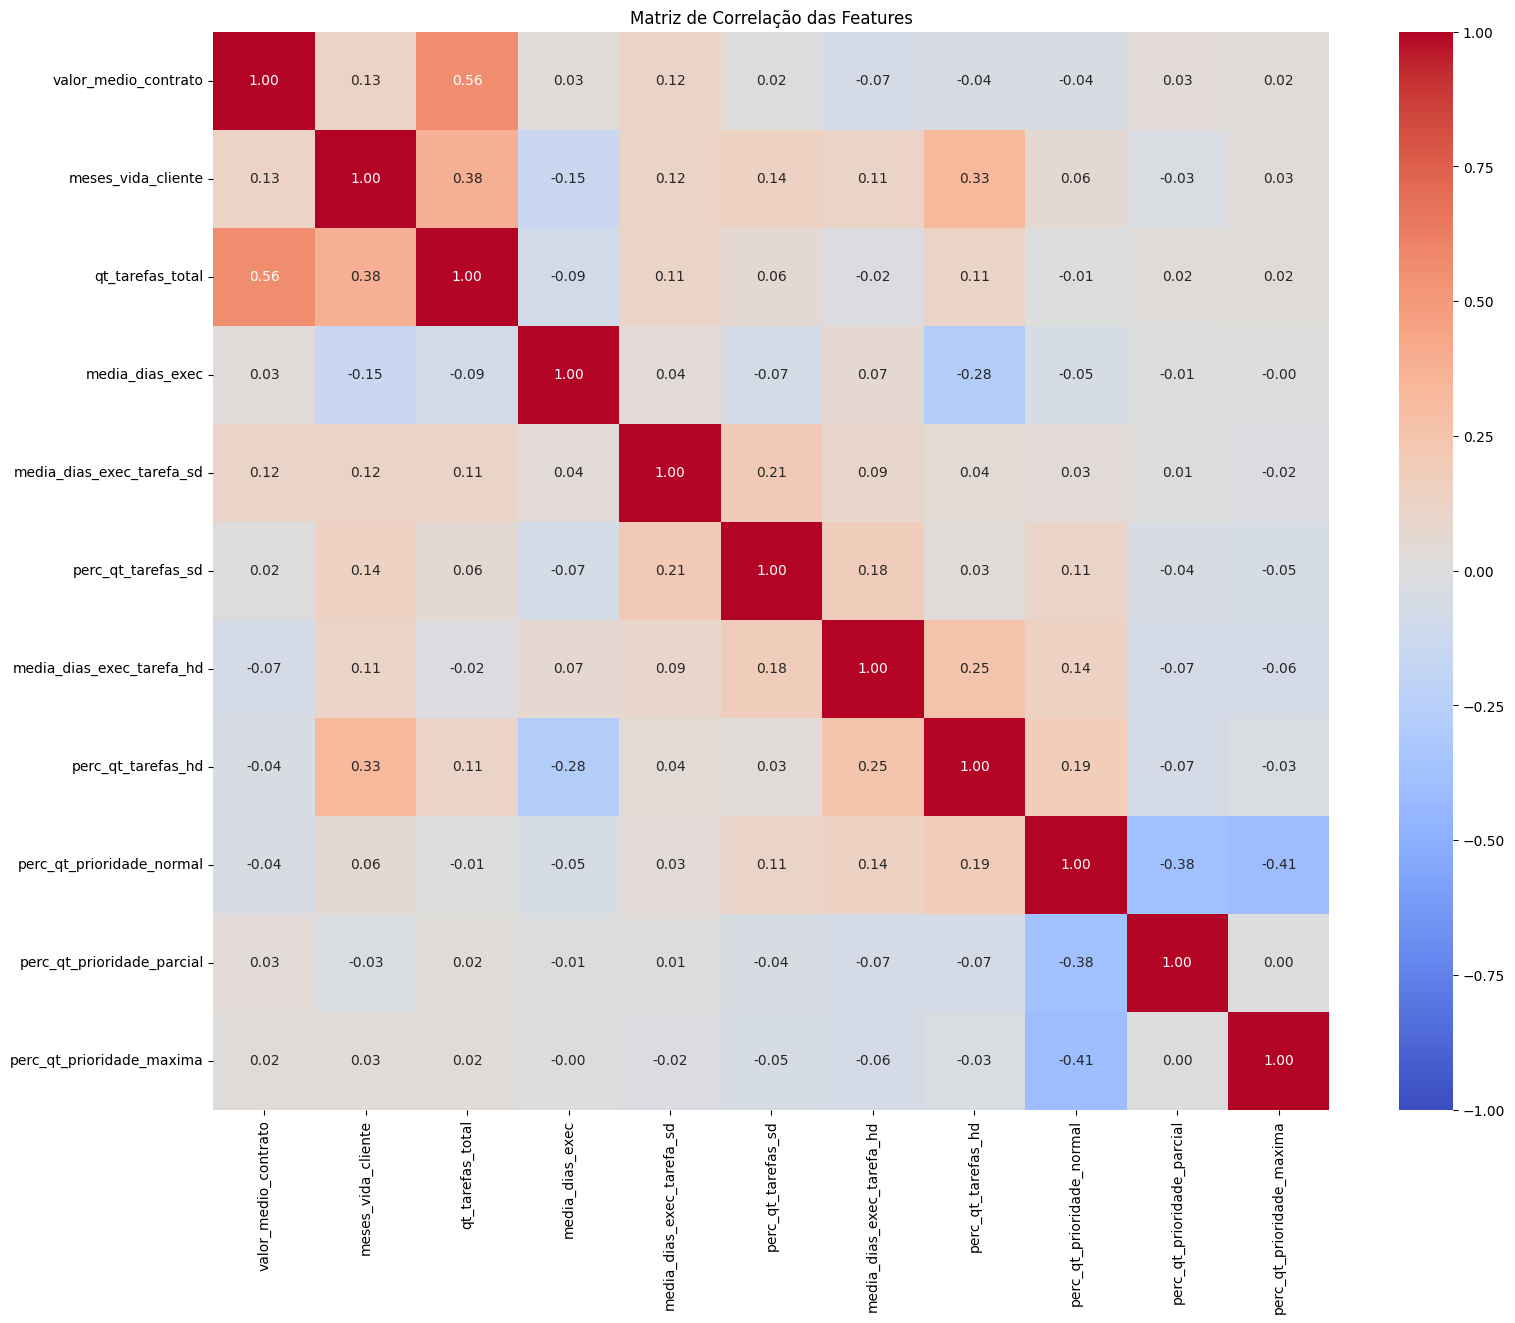

In [22]:
# Calculando a matriz de correlação de Pearson
plt.figure(figsize=(18, 14))
matrix_corr_limpa = X_limpo.corr()

# Plotando o Heatmap
sns.heatmap(matrix_corr_limpa, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação das Features")
plt.show()

In [23]:
# Filtrando correlações altas
upper_tri_limpo = matrix_corr_limpa.where(np.triu(np.ones(matrix_corr_limpa.shape), k=1).astype(bool))

to_drop_2 = [column for column in upper_tri_limpo.columns if any(abs(upper_tri_limpo[column]) >= 0.75)]

print(f"Sugestão de variáveis para exclusão por alta correlação: {to_drop_2}")

Sugestão de variáveis para exclusão por alta correlação: []


# Análise de Outliers

In [24]:
# DataFrame com as colunas que restaram após o drop de correlação
df_features = X_limpo.copy()

print("--- ANÁLISE QUANTITATIVA DE OUTLIERS (MÉTODO IQR) ---")
print(f"{'Métrica / Feature':<40} | {'qt Outliers':<12} | {'Porcentagem':<12}")
print("-" * 62)

colunas_com_outliers_criticos = []

for col in df_features.columns:
    # Ignora colunas que já são flags binárias (0 ou 1), pois nelas não existem outliers estatísticos
    if df_features[col].nunique() <= 2:
        continue

    Q1 = df_features[col].quantile(0.25)
    Q3 = df_features[col].quantile(0.75)
    IQR = Q3 - Q1

    # Definição estatística de Outlier: além de 1.5 vezes o IQR
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df_features[(df_features[col] < limite_inferior) | (df_features[col] > limite_superior)]
    total_outliers = len(outliers)
    porcentagem = (total_outliers / len(df_features)) * 100

    print(f"{col:<40} | {total_outliers:<12} | {porcentagem:.2f}%")

    # Se mais de 5% dos dados forem outliers, ou se houver um volume absoluto considerável
    if porcentagem > 5.0:
        colunas_com_outliers_criticos.append(col)

--- ANÁLISE QUANTITATIVA DE OUTLIERS (MÉTODO IQR) ---
Métrica / Feature                        | qt Outliers  | Porcentagem 
--------------------------------------------------------------
valor_medio_contrato                     | 436          | 10.72%
meses_vida_cliente                       | 71           | 1.75%
qt_tarefas_total                         | 469          | 11.53%
media_dias_exec                          | 345          | 8.48%
media_dias_exec_tarefa_sd                | 237          | 5.83%
perc_qt_tarefas_sd                       | 144          | 3.54%
media_dias_exec_tarefa_hd                | 147          | 3.61%
perc_qt_tarefas_hd                       | 0            | 0.00%
perc_qt_prioridade_normal                | 227          | 5.58%
perc_qt_prioridade_parcial               | 669          | 16.45%
perc_qt_prioridade_maxima                | 401          | 9.86%


In [25]:
# Dedivo à presença de outliers críticos,
# as variáveis numéricas serão padronizadas usando o RobustScaler,
# que é mais resistente a valores extremos para padronizar as features numéricas.

# Divisão de Treino/Teste e Padronização (Scaling)

In [26]:
# Separando os dados em Treino e Teste garantindo a mesma proporção de Churn (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X_limpo, y, test_size=0.10, random_state=42, stratify=y
)

# Padronizando as variáveis
# scaler = RobustScaler()
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Base de Treino: {X_train_scaled.shape[0]} amostras")
print(f"Base de Teste:  {X_test_scaled.shape[0]} amostras")

Base de Treino: 3661 amostras
Base de Teste:  407 amostras


In [27]:
# X_train_val, X_test, y_train_val, y_test = train_test_split(
#     X_limpo, y, test_size=0.10, random_state=42, stratify=y
# )

# X_train, X_calib, y_train, y_calib = train_test_split(
#     X_train_val, y_train_val, test_size=0.10, random_state=42, stratify=y_train_val
# )

# # Padronizando
# scaler = MinMaxScaler()
# # scaler = RobustScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_calib_scaled = scaler.transform(X_calib)
# X_test_scaled  = scaler.transform(X_test)

# print(f"Base de Treino:      {X_train_scaled.shape[0]} amostras")
# print(f"Base de Calibração:  {X_calib_scaled.shape[0]} amostras")
# print(f"Base de Teste:       {X_test_scaled.shape[0]} amostras")

## Salva Scaler

In [28]:
joblib.dump(scaler, 'src\\scaler_producao.pkl')

['src\\scaler_producao.pkl']

## Salva Features do Modelo

In [29]:
# Extrai os nomes das colunas na ordem exata do modelo
features_modelo = list(X_test.columns)

# Salva em um arquivo JSON
with open('src\\features_modelo.json', 'w', encoding='utf-8') as f:
    json.dump(features_modelo, f, ensure_ascii=False, indent=4)

# Regressão Logística

In [30]:
df_X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_train_sm        = sm.add_constant(df_X_train_scaled)
X_train_sm        = pd.DataFrame(X_train_sm, columns=['const'] + list(df_X_train_scaled.columns))

modelo_reglog = sm.Logit(y_train, X_train_sm).fit(method='bfgs', maxiter=1000)

Optimization terminated successfully.
         Current function value: 0.454597
         Iterations: 167
         Function evaluations: 168
         Gradient evaluations: 168


In [31]:
df_X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
X_test_sm        = sm.add_constant(df_X_test_scaled)
X_test_sm        = pd.DataFrame(X_test_sm, columns=['const'] + list(df_X_test_scaled.columns))

y_probs_reglog = modelo_reglog.predict(X_test_sm)

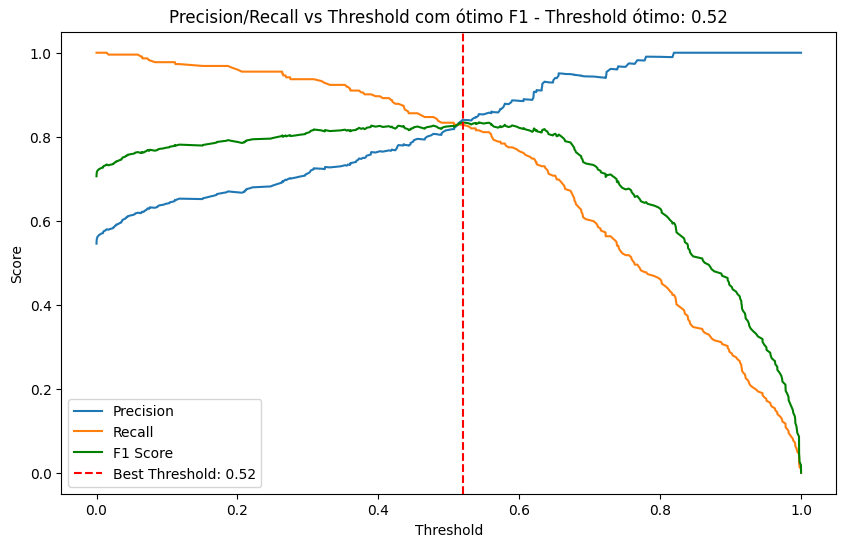

In [32]:
best_threshold_reglog = plot_analise_threshold(y_test, y_probs_reglog)

In [33]:
# Cria predição binária com base no threshold
y_pred_reglog = (y_probs_reglog >= best_threshold_reglog).astype(int)

In [34]:
recall_reglog   = recall_score(y_test, y_pred_reglog)
precisao_reglog = precision_score(y_test, y_pred_reglog)
acuracia_reglog = accuracy_score(y_test, y_pred_reglog)
f1_score_reglog = f1_score(y_test, y_pred_reglog)
roc_auc_reglog  = roc_auc_score(y_test, y_probs_reglog)

## Salva Modelo

In [35]:
joblib.dump(modelo_reglog, 'src\\modelo_reglog.pkl')

['src\\modelo_reglog.pkl']

## Importância das Features

In [36]:
# Extraindo Coeficientes e p-valores
df_importance = pd.DataFrame({
    'Feature':      df_X_train_scaled.columns,
    'Coefficient':  modelo_reglog.params.drop('const'),
    'p_value':      modelo_reglog.pvalues.drop('const')
}).reset_index(drop=True)

# Criando critério de significância estatística (p-valor < 0.05)
df_importance['Significativo'] = df_importance['p_value'].apply(
    lambda x: 'Sim (p < 0.05)' if x < 0.05 else 'Não (Irrelevante)'
    )

# Exibir tabela textual complementar
print(df_importance[['Feature', 'Coefficient', 'p_value', 'Significativo']].to_string(index=False))

                   Feature  Coefficient      p_value     Significativo
      valor_medio_contrato   -23.314480 1.619103e-12    Sim (p < 0.05)
        meses_vida_cliente    -8.633698 1.252025e-88    Sim (p < 0.05)
          qt_tarefas_total   -18.677886 1.069374e-04    Sim (p < 0.05)
           media_dias_exec     5.132661 1.501428e-07    Sim (p < 0.05)
 media_dias_exec_tarefa_sd    -3.248584 5.246233e-03    Sim (p < 0.05)
        perc_qt_tarefas_sd     3.766345 3.470750e-09    Sim (p < 0.05)
 media_dias_exec_tarefa_hd    13.628343 4.737683e-51    Sim (p < 0.05)
        perc_qt_tarefas_hd     0.265866 1.926779e-01 Não (Irrelevante)
 perc_qt_prioridade_normal     3.334336 1.231848e-09    Sim (p < 0.05)
perc_qt_prioridade_parcial    -2.313821 2.272958e-01 Não (Irrelevante)
 perc_qt_prioridade_maxima     7.426747 8.804751e-10    Sim (p < 0.05)


In [37]:
remove_colunas_nao_importantes = list(df_importance[df_importance['p_value'] > 0.05]['Feature'])
remove_colunas_nao_importantes

['perc_qt_tarefas_hd', 'perc_qt_prioridade_parcial']

In [38]:
X_train_scaled_logreg  = X_train_sm.drop(columns=remove_colunas_nao_importantes)
X_test_scaled_logreg   = X_test_sm.drop(columns=remove_colunas_nao_importantes)

modelo_reglog_limpo = sm.Logit(y_train, X_train_scaled_logreg).fit(method='bfgs', maxiter=1000)

y_probs_reglog_limpo = modelo_reglog_limpo.predict(X_test_scaled_logreg)

Optimization terminated successfully.
         Current function value: 0.455045
         Iterations: 140
         Function evaluations: 141
         Gradient evaluations: 141


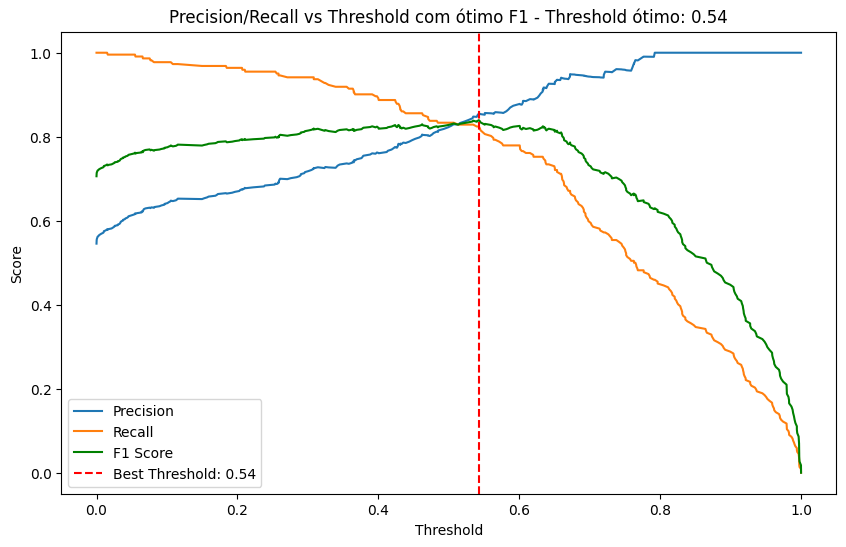

In [39]:
best_threshold_reglog_limpo = plot_analise_threshold(y_test, y_probs_reglog_limpo)

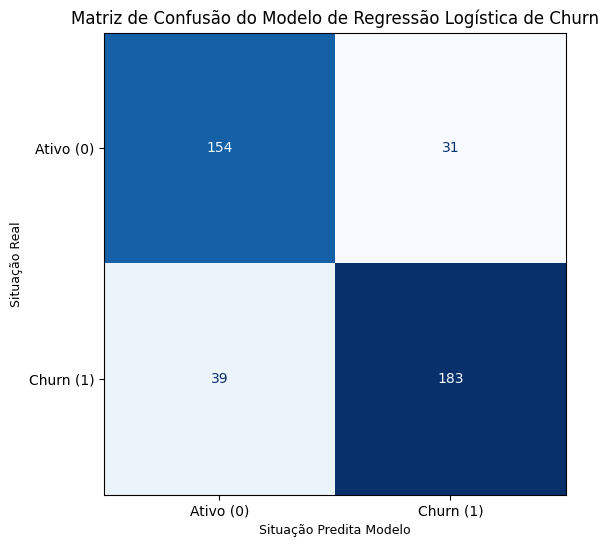

In [40]:
y_pred_reglog_limpo = (y_probs_reglog_limpo >= best_threshold_reglog_limpo).astype(int)

# Matriz de Confusão
cm_reglog_limpo = confusion_matrix(y_test, y_pred_reglog_limpo.values)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_reglog_limpo, display_labels=['Ativo (0)', 'Churn (1)'])
fig, ax = plt.subplots(figsize=(6, 6))
ax.grid(False)

disp.plot(cmap='Blues', values_format='d', colorbar=False, ax=ax) # 'd' força a exibição como número inteiro

plt.title('Matriz de Confusão do Modelo de Regressão Logística de Churn')
plt.ylabel('Situação Real', fontsize=9)
plt.xlabel('Situação Predita Modelo', fontsize=9)
plt.show()

ROC AUC Score: 0.90


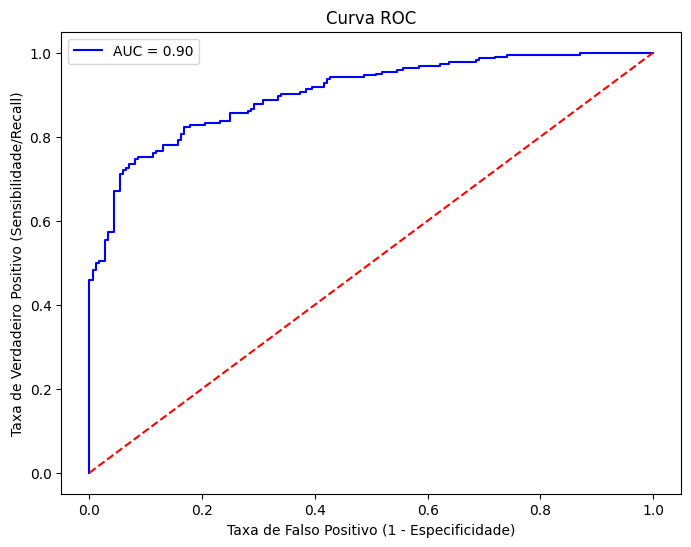

In [41]:
plot_curva_roc_auc(y_test, y_probs_reglog_limpo)

In [42]:
recall_reglog_limpo   = recall_score(y_test, y_pred_reglog_limpo)
precisao_reglog_limpo = precision_score(y_test, y_pred_reglog_limpo)
acuracia_reglog_limpo = accuracy_score(y_test, y_pred_reglog_limpo)
f1_score_reglog_limpo = f1_score(y_test, y_pred_reglog_limpo)
roc_auc_reglog_limpo  = roc_auc_score(y_test, y_probs_reglog_limpo)

In [43]:
# Extraindo Coeficientes e p-valores
df_importance_reglog_limpo = pd.DataFrame({
    'Feature':      X_train_scaled_logreg.drop(columns=['const']).columns,
    'Coefficient':  modelo_reglog_limpo.params.drop('const'),
    'p_value':      modelo_reglog_limpo.pvalues.drop('const')
}).reset_index(drop=True)

# Criando critério de significância estatística (p-valor < 0.05)
df_importance_reglog_limpo['Significativo'] = df_importance_reglog_limpo['p_value'].apply(
    lambda x: 'Sim (p < 0.05)' if x < 0.05 else 'Não (Irrelevante)'
    )

# Exibir tabela textual complementar
print(df_importance_reglog_limpo[['Feature', 'Coefficient', 'p_value', 'Significativo']].to_string(index=False))

                  Feature  Coefficient      p_value  Significativo
     valor_medio_contrato   -23.769877 5.704064e-13 Sim (p < 0.05)
       meses_vida_cliente    -8.512081 5.280978e-91 Sim (p < 0.05)
         qt_tarefas_total   -17.915139 1.444611e-04 Sim (p < 0.05)
          media_dias_exec     4.791401 2.381459e-07 Sim (p < 0.05)
media_dias_exec_tarefa_sd    -3.279203 4.370390e-03 Sim (p < 0.05)
       perc_qt_tarefas_sd     3.730952 4.638275e-09 Sim (p < 0.05)
media_dias_exec_tarefa_hd    13.882676 1.061662e-54 Sim (p < 0.05)
perc_qt_prioridade_normal     3.634667 1.467322e-11 Sim (p < 0.05)
perc_qt_prioridade_maxima     7.767889 1.820030e-10 Sim (p < 0.05)


## Salva Modelo

In [44]:
joblib.dump(modelo_reglog_limpo, 'src\\modelo_reglog_limpo.pkl')

['src\\modelo_reglog_limpo.pkl']

# Random Forest Classifier

In [45]:
pipeline_rf = Pipeline([
    ('modelo_rf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

pipeline_rf.fit(X_train, y_train)
modelo_rf = pipeline_rf.named_steps['modelo_rf']

y_pred_rf  = modelo_rf.predict(X_test)
y_probs_rf = modelo_rf.predict_proba(X_test)[:, 1]

In [46]:
baseline_recall_rf   = recall_score(y_test, y_pred_rf)
baseline_precisao_rf = precision_score(y_test, y_pred_rf)
baseline_acuracia_rf = accuracy_score(y_test, y_pred_rf)
baseline_f1_score_rf = f1_score(y_test, y_pred_rf)
baseline_roc_auc_rf  = roc_auc_score(y_test, y_probs_rf)

## Salva Modelo

In [47]:
joblib.dump(pipeline_rf, 'src\\pipeline_rf.pkl')
# joblib.dump(modelo_rf, 'src\\modelo_rf.pkl')

['src\\pipeline_rf.pkl']

## Importância das Features

In [48]:
importancia_features = modelo_rf.feature_importances_

coeficientes_churn_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importancia_absoluta': importancia_features
})

# Transformando em porcentagem de impacto na decisão do modelo
coeficientes_churn_rf['importancia_percentual'] = (coeficientes_churn_rf['importancia_absoluta'] * 100).round(2)

coeficientes_churn_rf = coeficientes_churn_rf.sort_values(by='importancia_absoluta',
                                                          ascending=False).reset_index(drop=True)

coeficientes_churn_rf

,feature,importancia_absoluta,importancia_percentual
0,valor_medio_contrato,0.190725,19.07
1,meses_vida_cliente,0.167772,16.78
2,qt_tarefas_total,0.143077,14.31
3,media_dias_exec_tarefa_hd,0.102192,10.22
4,perc_qt_prioridade_normal,0.084081,8.41
5,media_dias_exec,0.076204,7.62
6,perc_qt_tarefas_hd,0.065749,6.57
7,perc_qt_prioridade_parcial,0.046457,4.65
8,perc_qt_prioridade_maxima,0.045188,4.52
9,perc_qt_tarefas_sd,0.043939,4.39


## Tuning

In [49]:
param_grid_rf = {
    'modelo_rf_tuning__n_estimators':      randint(low=100, high=301),
    'modelo_rf_tuning__max_depth':         [None, 10, 20, 30],
    'modelo_rf_tuning__min_samples_split': randint(low=2, high=13),
    'modelo_rf_tuning__min_samples_leaf':  randint(low=1, high=6),
    'modelo_rf_tuning__bootstrap':         [True, False],
    'modelo_rf_tuning__max_features':      ["sqrt", "log2", None]
}

In [50]:
pipeline_rf_tuning = Pipeline([
    ('modelo_rf_tuning', RandomForestClassifier(random_state=42, n_jobs=-1))
])

random_search_rf = RandomizedSearchCV(
    estimator=pipeline_rf_tuning,
    param_distributions=param_grid_rf,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    verbose=3
)

random_search_rf.fit(X_train, y_train)

model_rf_tuning = random_search_rf.best_estimator_
print(f'\n{model_rf_tuning}')

y_pred_rf_tuning  = model_rf_tuning.predict(X_test)
y_probs_rf_tuning = model_rf_tuning.predict_proba(X_test)[:, 1]

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END modelo_rf_tuning__bootstrap=True, modelo_rf_tuning__max_depth=30, modelo_rf_tuning__max_features=sqrt, modelo_rf_tuning__min_samples_leaf=3, modelo_rf_tuning__min_samples_split=9, modelo_rf_tuning__n_estimators=288;, score=0.851 total time=   0.8s
[CV 2/5] END modelo_rf_tuning__bootstrap=True, modelo_rf_tuning__max_depth=30, modelo_rf_tuning__max_features=sqrt, modelo_rf_tuning__min_samples_leaf=3, modelo_rf_tuning__min_samples_split=9, modelo_rf_tuning__n_estimators=288;, score=0.836 total time=   0.9s
[CV 3/5] END modelo_rf_tuning__bootstrap=True, modelo_rf_tuning__max_depth=30, modelo_rf_tuning__max_features=sqrt, modelo_rf_tuning__min_samples_leaf=3, modelo_rf_tuning__min_samples_split=9, modelo_rf_tuning__n_estimators=288;, score=0.850 total time=   1.0s
[CV 4/5] END modelo_rf_tuning__bootstrap=True, modelo_rf_tuning__max_depth=30, modelo_rf_tuning__max_features=sqrt, modelo_rf_tuning__min_samples_leaf=3, m

In [51]:
recall_rf_tuning   = recall_score(y_test, y_pred_rf_tuning)
precisao_rf_tuning = precision_score(y_test, y_pred_rf_tuning)
acuracia_rf_tuning = accuracy_score(y_test, y_pred_rf_tuning)
f1_score_rf_tuning = f1_score(y_test, y_pred_rf_tuning)
roc_auc_rf_tuning  = roc_auc_score(y_test, y_probs_rf_tuning)

## Análise de Calibração

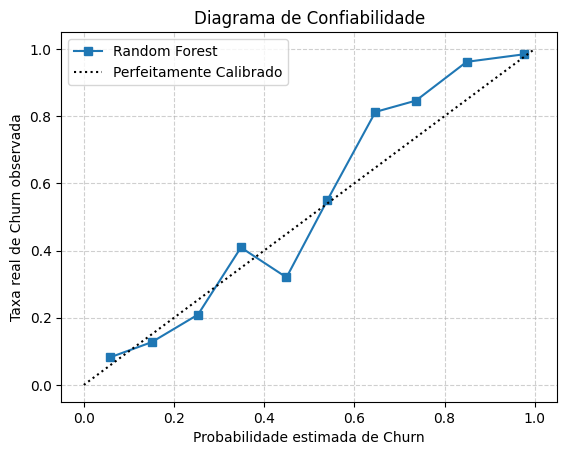

In [52]:
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, y_probs_rf_tuning, n_bins=10)

plt.plot(mean_predicted_value, fraction_of_positives, "s-", label='Random Forest')
plt.plot([0, 1], [0, 1], "k:", label='Perfeitamente Calibrado')
plt.xlabel("Probabilidade estimada de Churn")
plt.ylabel("Taxa real de Churn observada")
plt.title("Diagrama de Confiabilidade")
plt.legend(loc="upper left")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Salva Modelo

In [53]:
joblib.dump(pipeline_rf_tuning, 'src\\pipeline_rf_tuning.pkl')
# joblib.dump(model_rf_tuning, 'src\\model_rf_tuning.pkl')

['src\\pipeline_rf_tuning.pkl']

# XGBoost

In [54]:
# Para lidar com o desbalanceamento
scale_pos_weight = total_clientes_churn / total_clientes_nao_churn

pipeline_xgb = Pipeline([
    ('modelo_xgb',
     XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight))
])
# modelo_xgb = XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight)

# modelo_xgb.fit(X_train, y_train)
pipeline_xgb.fit(X_train, y_train)
modelo_xgb = pipeline_xgb.named_steps['modelo_xgb']

y_pred_xgb  = modelo_xgb.predict(X_test)
y_probs_xgb = modelo_xgb.predict_proba(X_test)[:, 1]


In [55]:
baseline_recall_xgb   = recall_score(y_test, y_pred_xgb)
baseline_precisao_xgb = precision_score(y_test, y_pred_xgb)
baseline_acuracia_xgb = accuracy_score(y_test, y_pred_xgb)
baseline_f1_score_xgb = f1_score(y_test, y_pred_xgb)
baseline_roc_auc_xgb  = roc_auc_score(y_test, y_probs_xgb)

## Salva Modelo

In [56]:
joblib.dump(pipeline_xgb, 'src\\pipeline_xgb.pkl')
# joblib.dump(modelo_xgb, 'src\\modelo_xgb.pkl')

['src\\pipeline_xgb.pkl']

## Importância das Features

In [57]:
importancia_features_xgb = modelo_xgb.feature_importances_

coeficientes_churn_xgb = pd.DataFrame({
    'feature': X_train.columns,
    'importancia_absoluta': importancia_features_xgb
})

# Transformando em porcentagem de impacto na decisão
coeficientes_churn_xgb['importancia_Percentual'] = (coeficientes_churn_xgb['importancia_absoluta'] * 100).round(2)

coeficientes_churn_xgb = coeficientes_churn_xgb.sort_values(by='importancia_absoluta',
                                                            ascending=False).reset_index(drop=True)

coeficientes_churn_xgb

,feature,importancia_absoluta,importancia_Percentual
0,valor_medio_contrato,0.189904,18.99
1,meses_vida_cliente,0.152057,15.21
2,qt_tarefas_total,0.118612,11.86
3,media_dias_exec_tarefa_hd,0.112204,11.22
4,perc_qt_prioridade_maxima,0.074525,7.45
5,perc_qt_prioridade_normal,0.073796,7.38
6,perc_qt_prioridade_parcial,0.066743,6.67
7,perc_qt_tarefas_sd,0.055771,5.58
8,perc_qt_tarefas_hd,0.055738,5.57
9,media_dias_exec_tarefa_sd,0.053088,5.31


## Análise SHAP

--- VISÃO GLOBAL DE IMPACTO DAS FEATURES ---


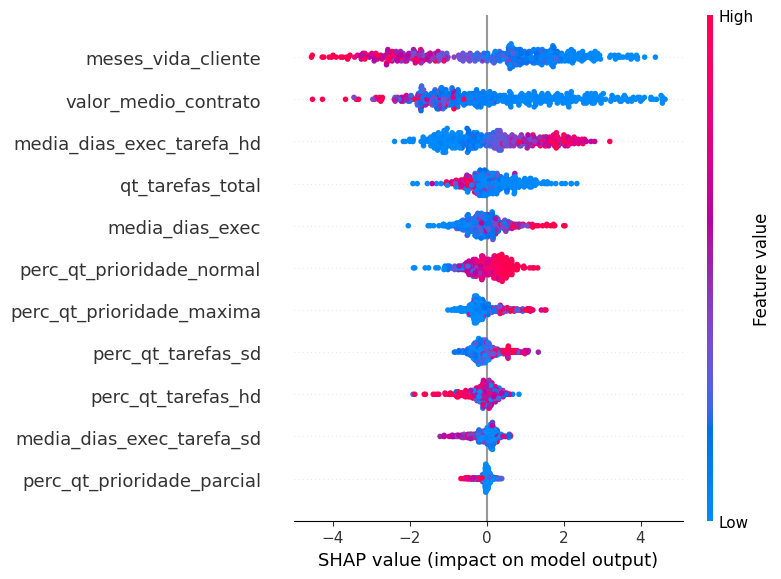


--- AUDITORIA INDIVIDUAL: POR QUE ESTE CLIENTE RECEBEU ESSE SCORE? ---


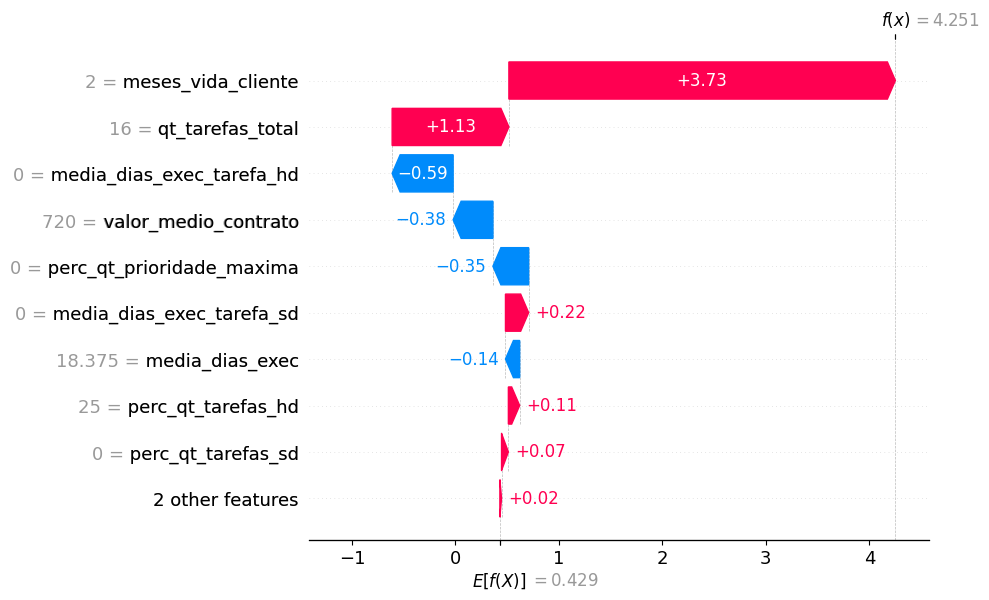

In [58]:
# Inicializa o renderizador de JavaScript para exibir os gráficos no Notebook
shap.initjs()

explainer = shap.TreeExplainer(modelo_xgb)

X_test_shap = pd.DataFrame(X_test, columns=X_test.columns)
shap_values = explainer(X_test_shap)

print("--- VISÃO GLOBAL DE IMPACTO DAS FEATURES ---")
shap.summary_plot(shap_values, X_test_shap)

# Pega o primeiro cliente do set de teste (índice 0) para auditar o porquê do score dele
print("\n--- AUDITORIA INDIVIDUAL: POR QUE ESTE CLIENTE RECEBEU ESSE SCORE? ---")
shap.plots.waterfall(shap_values[0])

## Tuning

In [59]:
param_dist_xgb = {
    'modelo_xgb_tuning__learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'modelo_xgb_tuning__n_estimators':     randint(100, 500),
    'modelo_xgb_tuning__max_depth':        randint(3, 10),
    'modelo_xgb_tuning__subsample':        [0.6, 0.7, 0.8, 0.9, 1.0],
    'modelo_xgb_tuning__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'modelo_xgb_tuning__gamma':            [0, 0.1, 0.2, 0.5],
    'modelo_xgb_tuning__scale_pos_weight': [scale_pos_weight] 
}

In [61]:
pipeline_xgb_tuning = Pipeline([
    ('modelo_xgb_tuning', XGBClassifier(random_state=42, eval_metric='logloss'))
])

random_search_xgb = RandomizedSearchCV(
    estimator=pipeline_xgb_tuning,
    param_distributions=param_dist_xgb,
    n_iter=50,
    cv=5,
    scoring='f1',
    verbose=3,
    random_state=42
)

random_search_xgb.fit(X_train, y_train)

model_xgb_tuning = random_search_xgb.best_estimator_
print(f'\n{model_xgb_tuning}')

y_pred_xgb_tuning  = model_xgb_tuning.predict(X_test)
y_probs_xgb_tuning = model_xgb_tuning.predict_proba(X_test)[:, 1]

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END modelo_xgb_tuning__colsample_bytree=0.9, modelo_xgb_tuning__gamma=0, modelo_xgb_tuning__learning_rate=0.1, modelo_xgb_tuning__max_depth=5, modelo_xgb_tuning__n_estimators=171, modelo_xgb_tuning__scale_pos_weight=1.2036836403033586, modelo_xgb_tuning__subsample=1.0;, score=0.850 total time=   5.4s
[CV 2/5] END modelo_xgb_tuning__colsample_bytree=0.9, modelo_xgb_tuning__gamma=0, modelo_xgb_tuning__learning_rate=0.1, modelo_xgb_tuning__max_depth=5, modelo_xgb_tuning__n_estimators=171, modelo_xgb_tuning__scale_pos_weight=1.2036836403033586, modelo_xgb_tuning__subsample=1.0;, score=0.856 total time=   0.5s
[CV 3/5] END modelo_xgb_tuning__colsample_bytree=0.9, modelo_xgb_tuning__gamma=0, modelo_xgb_tuning__learning_rate=0.1, modelo_xgb_tuning__max_depth=5, modelo_xgb_tuning__n_estimators=171, modelo_xgb_tuning__scale_pos_weight=1.2036836403033586, modelo_xgb_tuning__subsample=1.0;, score=0.861 total time=   0.5s
[CV 4

In [62]:
recall_xgb_tuning   = recall_score(y_test, y_pred_xgb_tuning)
precisao_xgb_tuning = precision_score(y_test, y_pred_xgb_tuning)
acuracia_xgb_tuning = accuracy_score(y_test, y_pred_xgb_tuning)
f1_score_xgb_tuning = f1_score(y_test, y_pred_xgb_tuning)
roc_auc_xgb_tuning  = roc_auc_score(y_test, y_probs_xgb_tuning)

## Análise de Calibração

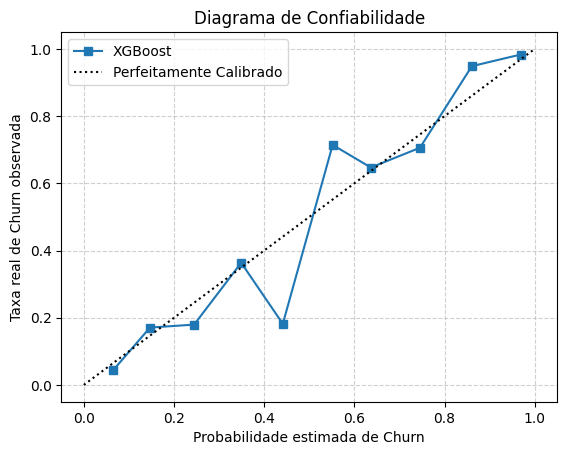

In [63]:
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, y_probs_xgb_tuning, n_bins=10)

plt.plot(mean_predicted_value, fraction_of_positives, "s-", label='XGBoost')
plt.plot([0, 1], [0, 1], "k:", label='Perfeitamente Calibrado')
plt.xlabel("Probabilidade estimada de Churn")
plt.ylabel("Taxa real de Churn observada")
plt.title("Diagrama de Confiabilidade")
plt.legend(loc="upper left")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Salva Modelo

In [64]:
joblib.dump(pipeline_xgb_tuning, 'src\\pipeline_xgb_tuning.pkl')
# joblib.dump(model_xgb_tuning, 'src\\model_xgb_tuning.pkl')

['src\\pipeline_xgb_tuning.pkl']

# Compara Métricas

In [65]:
# Estruturando os dados
dados_metricas = {
    "modelo": [
        "Regressão Logística",
        "Regressão Logística Limpa",
        "Random Forest",
        "Random Forest Tuning",
        "XGBoost",
        "XGBoost Tuning"
    ]
    * 5,
    "metrica": (
        ["Precisão"]    * 6
        + ["Recall"]    * 6
        + ["Acurácia"]  * 6
        + ["F1-Score"]  * 6
        + ["ROC AUC"]   * 6
    ),
    "valor": [
        precisao_reglog,
        precisao_reglog_limpo,
        baseline_precisao_rf,
        precisao_rf_tuning,
        baseline_precisao_xgb,
        precisao_xgb_tuning,

        recall_reglog,
        recall_reglog_limpo,
        baseline_recall_rf,
        recall_rf_tuning,
        baseline_recall_xgb,
        recall_xgb_tuning,
        
        acuracia_reglog,
        acuracia_reglog_limpo,
        baseline_acuracia_rf,
        acuracia_rf_tuning,
        baseline_acuracia_xgb,
        acuracia_xgb_tuning,
        
        f1_score_reglog,
        f1_score_reglog_limpo,
        baseline_f1_score_rf,
        f1_score_rf_tuning,
        baseline_f1_score_xgb,
        f1_score_xgb_tuning,
        
        roc_auc_reglog,
        roc_auc_reglog_limpo,
        baseline_roc_auc_rf,
        roc_auc_rf_tuning,
        baseline_roc_auc_xgb,
        roc_auc_xgb_tuning,
    ]
}

df_metrics = pd.DataFrame(dados_metricas)
df_metrics

,modelo,metrica,valor
0,Regressão Logística,Precisão,0.840183
1,Regressão Logística Limpa,Precisão,0.855140
2,Random Forest,Precisão,0.920398
3,Random Forest Tuning,Precisão,0.915423
4,XGBoost,Precisão,0.896714
5,XGBoost Tuning,Precisão,0.901869
6,Regressão Logística,Recall,0.828829
7,Regressão Logística Limpa,Recall,0.824324
8,Random Forest,Recall,0.833333
9,Random Forest Tuning,Recall,0.828829


## Plot

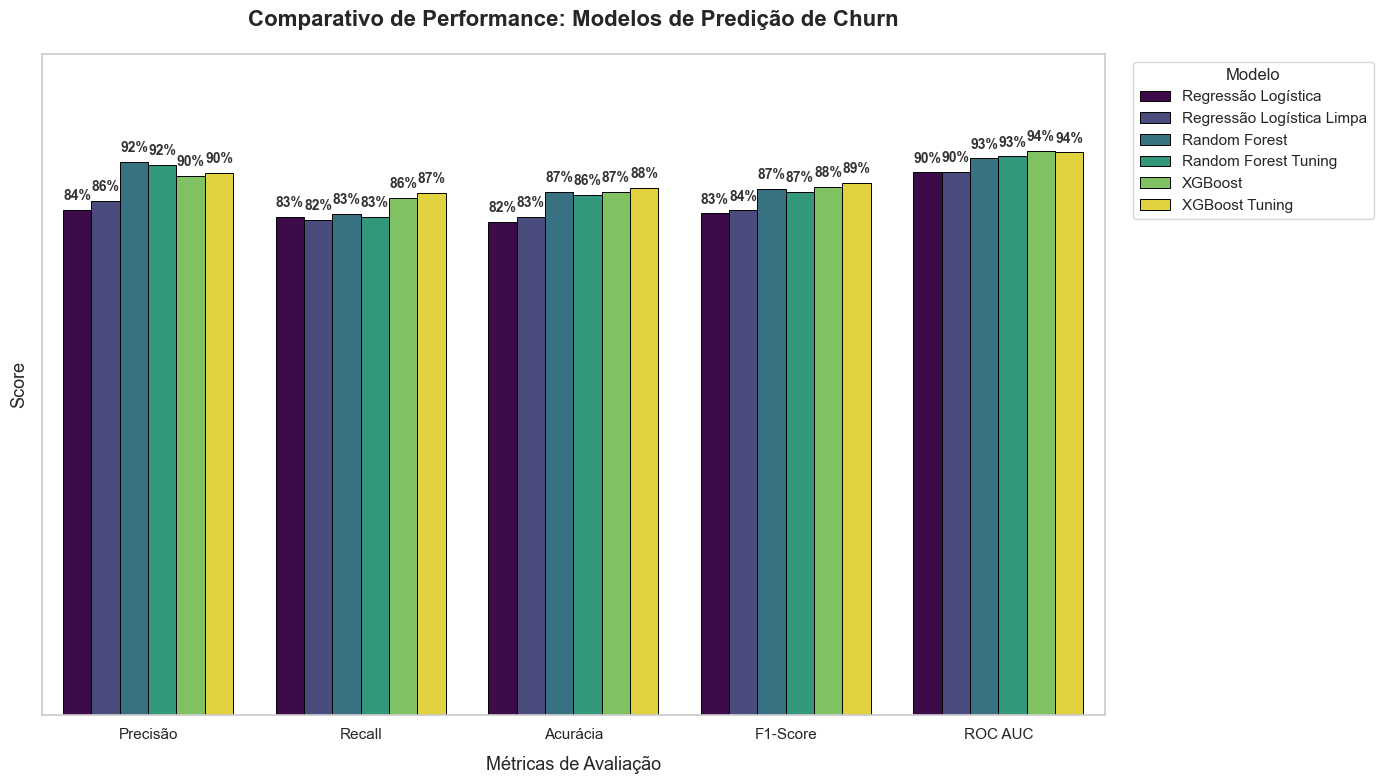

In [66]:
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

cores = [
    "#440154",
    "#414487",
    "#2a788e",
    "#22a884",
    "#7ad151",
    "#fde725"
]

ax = sns.barplot(
    data=df_metrics,
    x="metrica",
    y="valor",
    hue="modelo",
    palette=cores,
    edgecolor="black",
    linewidth=0.7,
)

plt.title(
    "Comparativo de Performance: Modelos de Predição de Churn",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Métricas de Avaliação", fontsize=13, labelpad=10)
plt.ylabel("Score", fontsize=13, labelpad=10)
plt.ylim(0, 1.1)
plt.yticks([], [])

plt.legend(
    title="Modelo",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=11,
    title_fontsize=12,
)

# Adicionando os valores exatos em cima de cada barra automaticamente
for p in ax.patches:
    if (p.get_height() > 0):  # Garante que só vai plotar se a barra tiver altura
        ax.annotate(
            f"{p.get_height() * 100:.0f}%",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="center",
            xytext=(0, 10),
            textcoords="offset points",
            fontsize=10,
            fontweight="bold",
            color="#333333",
        )

plt.tight_layout()
plt.show()

In [67]:
# Matriz de Confusão
cm_reglog       = confusion_matrix(y_test, y_pred_reglog)
cm_reglog_limpo = confusion_matrix(y_test, y_pred_reglog_limpo)

cm_rf       = confusion_matrix(y_test, y_pred_rf)
cm_rf_tuning = confusion_matrix(y_test, y_pred_rf_tuning)

cm_xgb       = confusion_matrix(y_test, y_pred_xgb)
cm_xgb_tuning = confusion_matrix(y_test, y_pred_xgb_tuning)

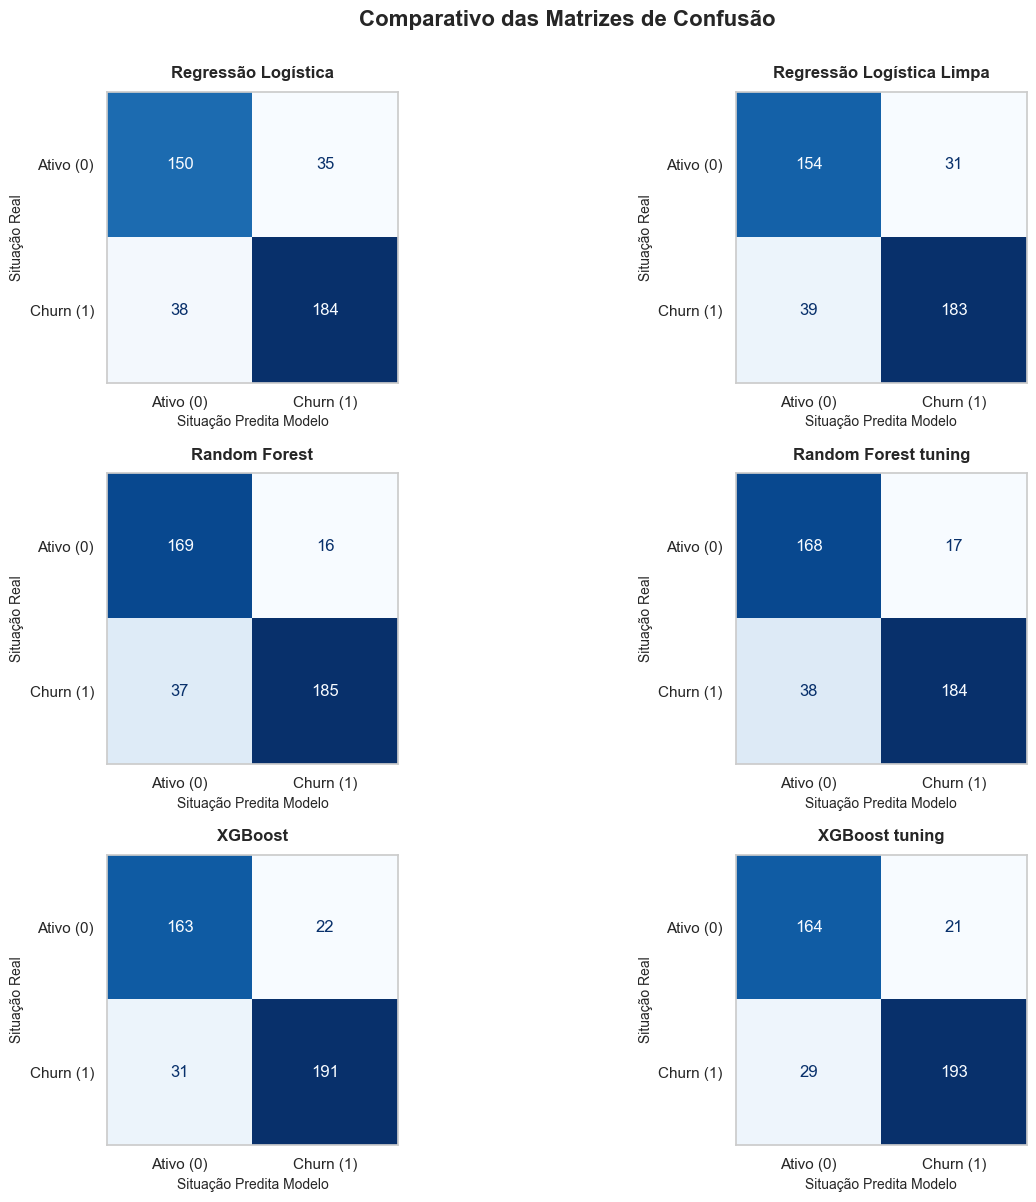

In [68]:
# Matrizes de confusão
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Comparativo das Matrizes de Confusão', fontsize=16, fontweight='bold', y=1)

# Lista de configurações para iterar no loop
modelos = [
    {"cm": cm_reglog,        "title": "Regressão Logística",        "ax": axes[0, 0]},
    {"cm": cm_reglog_limpo,  "title": "Regressão Logística Limpa",  "ax": axes[0, 1]},
    {"cm": cm_rf,            "title": "Random Forest",              "ax": axes[1,0]},
    {"cm": cm_rf_tuning,      "title": "Random Forest tuning",        "ax": axes[1, 1]},
    {"cm": cm_xgb,           "title": "XGBoost",                    "ax": axes[2, 0]},
    {"cm": cm_xgb_tuning,     "title": "XGBoost tuning",              "ax": axes[2, 1]}
]

# Plotar cada matriz no seu respectivo 'ax'
for mod in modelos:
    mod["ax"].grid(False)  # Remove linhas de grade que desalinhame a matriz
    disp = ConfusionMatrixDisplay(
        confusion_matrix=mod["cm"],
        display_labels=['Ativo (0)',
                        'Churn (1)']
                        )

    # O segredo está em passar o 'ax' correto para o plot
    disp.plot(cmap='Blues', values_format='d', colorbar=False, ax=mod["ax"])

    # Customizações por sub-plot
    mod["ax"].set_title(mod["title"], fontsize=12, fontweight='bold', pad=10)
    mod["ax"].set_ylabel('Situação Real', fontsize=10)
    mod["ax"].set_xlabel('Situação Predita Modelo', fontsize=10)

plt.tight_layout()
plt.show()

## Análise de Cutoff

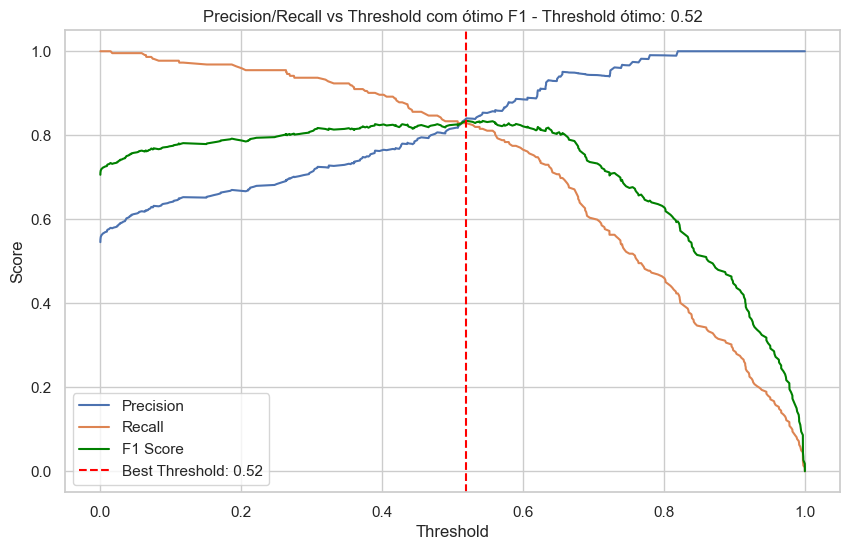

0.519636075366708

In [69]:
plot_analise_threshold(y_test, y_probs_reglog)

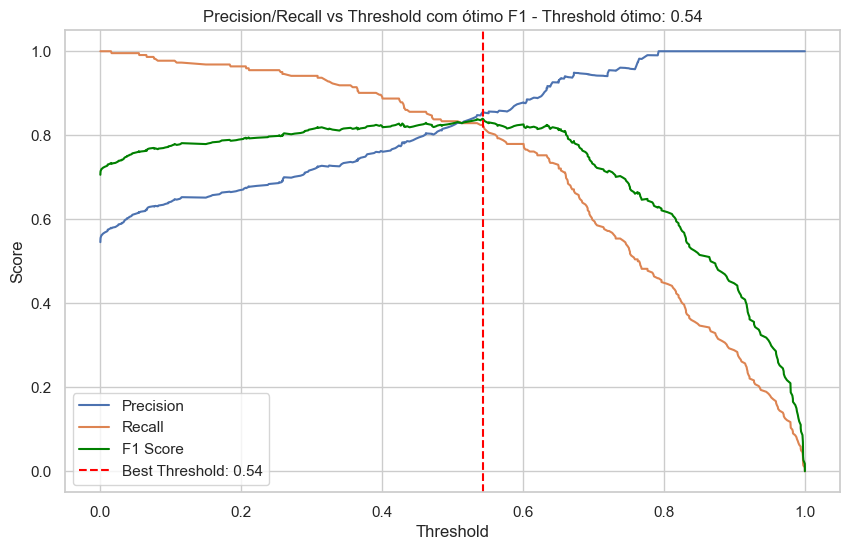

0.5426628140333549

In [70]:
plot_analise_threshold(y_test, y_probs_reglog_limpo)

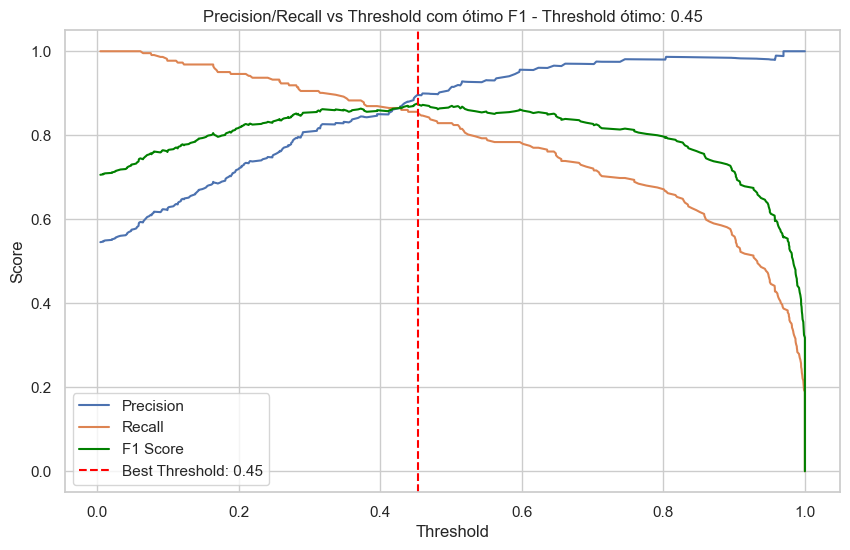

0.4528288040645455

In [71]:
plot_analise_threshold(y_test, y_probs_rf_tuning)

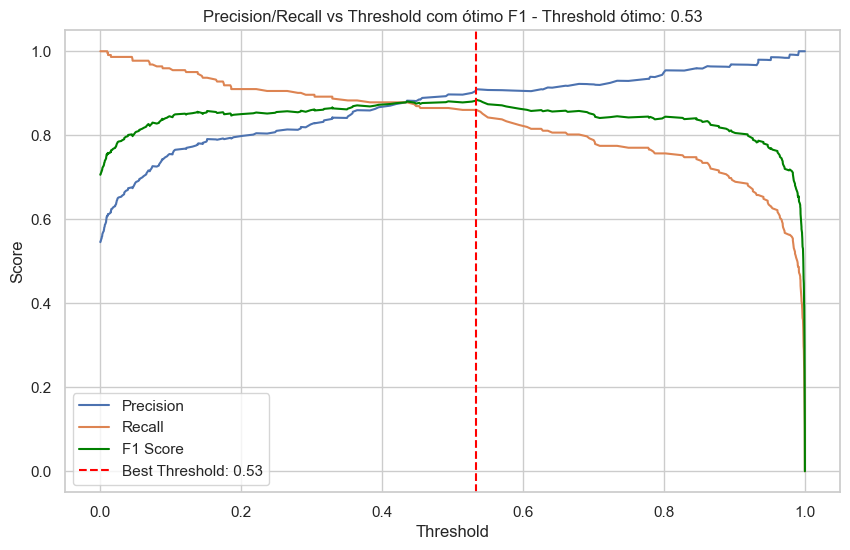

0.5339862108230591

In [72]:
plot_analise_threshold(y_test, y_probs_xgb)

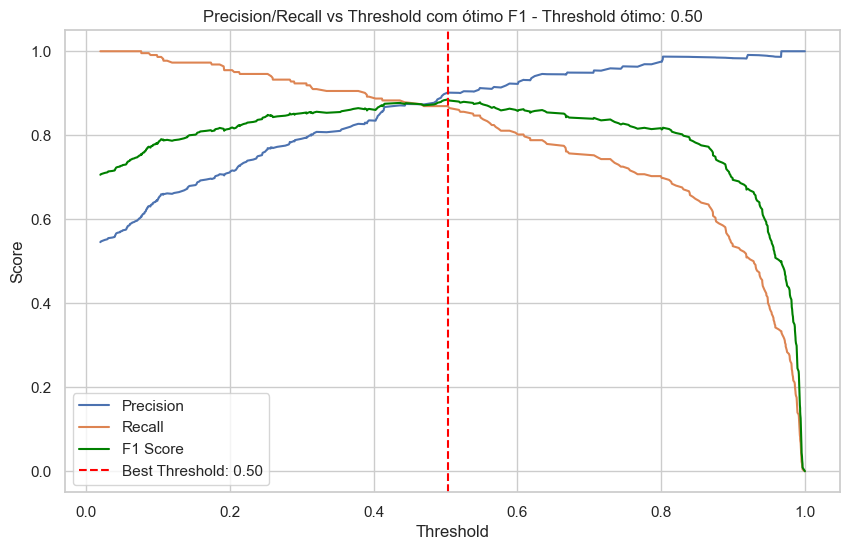

0.5034441351890564

In [73]:
plot_analise_threshold(y_test, y_probs_xgb_tuning)